<style>
.jp-RenderedHTMLCommon, .jp-RenderedMarkdown, .output_area {
  font-family: "Times New Roman", Times, serif;
  font-size: 12pt;
}
</style>

# Complete reproducible analysis: DAG-guided benchmarking of causal machine learning for Parvovirus B19 IgG serostatus: a simulation study and data-quality audit

**Companion to the Research Article submitted to BMC Medical Research Methodology**  
**Analysis validation date:** 7 August 2026  
**Locked base seed:** 20260730

This reader-facing notebook contains the complete code used for the cohort audit, parametric simulation, DoubleMLIRM analysis, CausalForestDML heterogeneity benchmark, tabular synthetic-data comparison, and manuscript figures. It deliberately separates three evidence layers:

1. the protected hospital workbook, used only for an aggregate quality audit and descriptive context;
2. parametric simulations, used for all causal estimator claims because their causal truth is known; and
3. a train-synthetic/test-real benchmark, used only to compare synthesis diagnostics.

**Privacy:** Patient ID and name columns are discarded during ingestion and are never stored in a notebook data frame or displayed. No patient-level or small-cell output is produced. Do not attach the source workbook to a public submission or repository.

**Execution modes:** `RUN_FULL_ANALYSIS=False` (the submitted default) verifies the locked outputs and manuscript claims in minutes. Setting it to `True` recomputes the full Monte Carlo and synthetic-data analyses and may take approximately 35 minutes or longer on four CPU threads.

**Generative-AI disclosure:** OpenAI Codex assisted with code scaffolding, language editing, reference checking, and document formatting. The executable cells, locked-output checks, and manuscript reconciliation are exposed for human review. The named authors retain responsibility for validating the code, outputs, interpretation, and institutional data-governance compliance before submission.

## tl;dr

- The source workbook contained 368 records; nine borderline labels were excluded, leaving 359 definitive records (172 positive, 187 negative; 47.9% positive).
- The real cohort did **not** define a defensible causal treatment/control contrast. It is therefore used descriptively, not to estimate a causal effect.
- In cohort-sized identified scenarios, logistic DoubleML had small bias and approximately nominal interval coverage. Limited overlap increased RMSE; deliberately omitted confounding and outcome misclassification produced bias against the latent target.
- CausalForestDML recovered heterogeneous rankings poorly at n=359 and better, though still imperfectly, at n=1000; patient-level interpretations are not supported.
- Synthetic generators ranked differently by fidelity, held-out predictive utility, and distance diagnostics. TVAE’s 92.3% exact benchmark-field match rate constitutes catastrophic overfitting and memorization under the prespecified release screen; no patient-level synthetic data should be released from this study.

## Context & Methods

### Key assumptions

- The clinical data custodian verified that age was recorded in completed years.
- Immunoglobulin G testing used the SERION ELISA classic assay (ESR122G; lots EP0160 and EO0207) with a Bio-Rad PR 4100 reader. Labels are accepted as recorded because the archived workbook does not contain the lot-specific calibration curve, control readings, or numerical cut-offs needed for independent reconstruction.
- Clinical strata are descriptive admission/testing labels, not verified interventions. `NA` is mapped to *Unspecified*, not to an unexposed control.
- One missing age was median-imputed before the synthetic train-holdout split. CBC variables are excluded because RBC/TLC scales change by workbook block; liver and renal variables are excluded rather than imputed because 89-96% of values are missing.
- The simulated exposure `A` is hypothetical and is not mapped to any observed diagnosis or clinical stratum.
- Under outcome misclassification, performance is evaluated against the latent-outcome ATE.
- Exact-match and nearest-neighbour measures are release screens, not numerical re-identification probabilities or privacy guarantees; the TVAE result is nevertheless an unequivocal release failure.

The Monte Carlo design follows ADEMP: aims, data-generating mechanisms, estimands, methods, and performance measures. Five-fold cross-fitting, repeated sample partitions, deterministic seeds, Monte Carlo standard errors, and assumption-violation scenarios are prespecified below.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import re
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display
from openpyxl import load_workbook

PACKAGE_ROOT = Path.cwd()
SOURCE_WORKBOOK = Path(os.environ.get("B19_WORKBOOK", PACKAGE_ROOT / "source_patient_data.xlsx"))
RUN_FULL_ANALYSIS = False  # Set True only when a complete, time-intensive recomputation is intended.
JOBS = 4
BASE_SEED = 20260730

print({
    "python": platform.python_version(),
    "package_root": str(PACKAGE_ROOT),
    "protected_source_available": SOURCE_WORKBOOK.exists(),
    "run_full_analysis": RUN_FULL_ANALYSIS,
    "jobs": JOBS,
})

{'python': '3.12.14', 'package_root': '.', 'protected_source_available': False, 'run_full_analysis': False, 'jobs': 4}


## Data

### 1. Privacy-safe workbook ingestion and aggregate audit

The loader confirms the identifier-column headers and immediately slices them away. It never constructs a data frame containing patient IDs or names. Only aggregate checks are displayed. If the protected workbook is unavailable, the notebook remains executable in locked-output verification mode; full source and synthetic recomputation then remains intentionally unavailable.

In [2]:
NUMERIC_COLUMNS = [
    "Hb", "RBC", "TLC", "Platelets", "HBV", "HCV", "HIV", "ALT", "AST",
    "ALP", "T. Bil", "Urea", "Creat", "Uric Acid", "Raw Data", "BLK OD", "Final OD",
]


def load_deidentified_workbook(path: Path) -> pd.DataFrame:
    workbook = load_workbook(path, read_only=True, data_only=True)
    worksheet = workbook["Sheet1"]
    headers = [cell.value for cell in worksheet[5]]
    assert headers[:2] == ["Patient ID", "Name"], "Identifier columns changed; stop and review schema."
    safe_headers = headers[2:]
    safe_rows = [list(row)[2:] for row in worksheet.iter_rows(min_row=6, values_only=True)]
    frame = pd.DataFrame(safe_rows, columns=safe_headers)
    frame = frame.loc[frame.notna().any(axis=1)].reset_index(drop=True)
    assert "Patient ID" not in frame and "Name" not in frame
    return frame


def clinical_stratum(value: object) -> str:
    value = "" if pd.isna(value) else str(value).strip().lower()
    if value == "pregnancy": return "Pregnancy"
    if value == "nephrotic": return "Renal"
    if value in {"hepatitis", "hepatic", "heaptic", "liver"}: return "Hepatic"
    if value == "fever": return "Fever"
    if value in {"surgery", "medical", "thalsemic", "anemic"}: return "Other clinical"
    return "Unspecified"


def audit_source(frame: pd.DataFrame) -> tuple[pd.DataFrame, dict, pd.DataFrame]:
    checked = frame.copy()
    for column in NUMERIC_COLUMNS:
        checked[column] = pd.to_numeric(checked[column], errors="coerce")
    checked["outcome"] = checked["POS/NEG"].astype(str).str.strip().str.title()
    checked["gender"] = checked["Gender"].astype(str).str.strip().str.title()
    checked["age_years"] = pd.to_numeric(
        checked["Age"].astype(str).str.extract(r"([-+]?\d*\.?\d+)", expand=False),
        errors="coerce",
    )
    definitive = checked.loc[checked["outcome"].isin(["Positive", "Negative"])].copy()
    definitive["clinical_stratum"] = definitive["Disease"].map(clinical_stratum)
    definitive["positive"] = (definitive["outcome"] == "Positive").astype(int)

    residual = checked["Raw Data"] - checked["BLK OD"] - checked["Final OD"]
    swap_signature = (checked["RBC"] > 100) & (checked["TLC"] < 100)
    normal_signature = (checked["RBC"] < 20) & (checked["TLC"] > 100)
    lft_rft = ["ALT", "AST", "ALP", "T. Bil", "Urea", "Creat", "Uric Acid"]
    audit = {
        "source_records": int(len(checked)),
        "definitive_records": int(len(definitive)),
        "positive": int((definitive["outcome"] == "Positive").sum()),
        "negative": int((definitive["outcome"] == "Negative").sum()),
        "borderline_excluded": int((checked["outcome"] == "Borderline").sum()),
        "age_missing_definitive": int(definitive["age_years"].isna().sum()),
        "od_complete_rows": int(residual.notna().sum()),
        "od_max_absolute_residual": float(residual.abs().max()),
        "rbc_tlc_swap_signature_rows": int(swap_signature.sum()),
        "rbc_tlc_normal_signature_rows": int(normal_signature.sum()),
        "lft_rft_missingness_range_percent": (
            float(100 * checked[lft_rft].isna().mean().min()),
            float(100 * checked[lft_rft].isna().mean().max()),
        ),
    }
    strata = definitive.groupby("clinical_stratum", as_index=False).agg(
        n=("positive", "size"), positive=("positive", "sum")
    )
    strata["positive_percent"] = 100 * strata["positive"] / strata["n"]
    return checked, audit, strata.sort_values("n", ascending=False).reset_index(drop=True)


if SOURCE_WORKBOOK.exists():
    cohort_df = load_deidentified_workbook(SOURCE_WORKBOOK)
    cohort_checked, cohort_audit, cohort_strata = audit_source(cohort_df)
    assert cohort_audit["source_records"] == 368
    assert cohort_audit["definitive_records"] == 359
    assert cohort_audit["positive"] == 172 and cohort_audit["negative"] == 187
    assert cohort_audit["borderline_excluded"] == 9
    assert cohort_audit["od_max_absolute_residual"] <= 1e-9
    display(pd.DataFrame([cohort_audit]))
    display(cohort_strata)
else:
    cohort_df = None
    cohort_checked = None
    cohort_audit = json.loads((PACKAGE_ROOT / "cohort_audit_locked.json").read_text(encoding="utf-8"))
    cohort_strata = pd.read_csv(PACKAGE_ROOT / "cohort_strata_summary.csv")
    print("Protected workbook not present: using locked aggregate audit outputs only.")
    display(cohort_strata)


Protected workbook not present: using locked aggregate audit outputs only.


,domain,category,n,positive,positive_percent
0,Clinical stratum,Fever,10,4,40.000000
1,Clinical stratum,Hepatic,24,12,50.000000
2,Clinical stratum,Other clinical,7,3,42.857143
3,Clinical stratum,Pregnancy,193,87,45.077720
4,Clinical stratum,Renal,38,26,68.421053
5,Clinical stratum,Unspecified,87,40,45.977011


### 2. Complete simulation, DML, causal-forest, aggregation, and figure code

The following cell is the production analysis code. Function definitions execute quickly. The controlled execution cell that follows either recomputes the full analysis or loads the locked outputs generated with these functions.

In [3]:
from __future__ import annotations

import argparse
import json
import math
import platform
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import doubleml as dml
import econml
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sdv
import seaborn as sns
import sklearn
from doubleml import DoubleMLData, DoubleMLIRM
from econml.dml import CausalForestDML
from joblib import Parallel, delayed
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy.special import expit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold


ROOT = PACKAGE_ROOT
BASE_SEED = 20260730
Z95 = 1.959963984540054


@dataclass(frozen=True)
class Scenario:
    name: str
    effect: str
    overlap: str = "standard"
    unmeasured_confounding: bool = False
    outcome_misclassification: bool = False
    selective_missingness: bool = False


SCENARIOS = (
    Scenario("Null", "null"),
    Scenario("Homogeneous", "homogeneous"),
    Scenario("Heterogeneous", "heterogeneous"),
    Scenario("Limited overlap", "homogeneous", overlap="limited"),
    Scenario("Selective missingness", "homogeneous", selective_missingness=True),
    Scenario(
        "Unmeasured confounding",
        "homogeneous",
        unmeasured_confounding=True,
    ),
    Scenario(
        "Outcome misclassification",
        "homogeneous",
        outcome_misclassification=True,
    ),
)


def software_versions() -> dict[str, str]:
    return {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "scikit-learn": sklearn.__version__,
        "doubleml": dml.__version__,
        "econml": econml.__version__,
        "sdv": sdv.__version__,
        "matplotlib": matplotlib.__version__,
    }


def true_ate(effect: str) -> float:
    if effect == "null":
        return 0.0
    if effect == "homogeneous":
        return 0.10
    if effect == "heterogeneous":
        # X1 is symmetric about zero and P(female)=237/368.
        return 0.03 + 0.04 * 0.5 + 0.05 * (237 / 368)
    raise ValueError(effect)


def simulate_data(
    n: int,
    scenario: Scenario,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict[str, float]]:
    rng = np.random.default_rng(seed)
    age_z = rng.normal(size=n)
    female = rng.binomial(1, 237 / 368, size=n)
    urban_proxy = rng.binomial(1, 0.90, size=n)
    u = rng.normal(size=n)
    x = np.column_stack((age_z, female, urban_proxy))

    baseline_index = (
        -0.45
        + 0.55 * age_z
        - 0.35 * female
        + 0.25 * urban_proxy
        + 0.30 * np.sin(age_z)
        + 0.18 * age_z**2
    )
    p0 = 0.08 + 0.42 * expit(baseline_index)
    if scenario.unmeasured_confounding:
        p0 = p0 + 0.08 * expit(u)

    if scenario.effect == "null":
        tau = np.zeros(n)
    elif scenario.effect == "homogeneous":
        tau = np.full(n, 0.10)
    elif scenario.effect == "heterogeneous":
        tau = 0.03 + 0.04 * (age_z > 0) + 0.05 * female
    else:
        raise ValueError(scenario.effect)
    p1 = p0 + tau

    if scenario.overlap == "limited":
        propensity = 0.01 + 0.98 * expit(
            -0.75 + 2.30 * age_z - 1.80 * female + 1.15 * urban_proxy
        )
    else:
        propensity = 0.08 + 0.84 * expit(
            -0.30
            + 0.60 * age_z
            - 0.55 * female
            + 0.30 * urban_proxy
            + 0.25 * np.sin(age_z)
        )
    if scenario.unmeasured_confounding:
        propensity = 0.03 + 0.94 * expit(
            np.log(propensity / (1 - propensity)) + 1.15 * u
        )

    treatment = rng.binomial(1, propensity)
    latent_probability = np.where(treatment == 1, p1, p0)
    latent_outcome = rng.binomial(1, latent_probability)
    observed_outcome = latent_outcome.copy()
    if scenario.outcome_misclassification:
        sensitivity, specificity = 0.85, 0.95
        positive = latent_outcome == 1
        observed_outcome[positive] = rng.binomial(
            1, sensitivity, size=int(positive.sum())
        )
        observed_outcome[~positive] = rng.binomial(
            1, 1 - specificity, size=int((~positive).sum())
        )

    observed_fraction = 1.0
    if scenario.selective_missingness:
        observation_probability = 0.25 + 0.70 * expit(
            1.00 - 0.60 * female + 0.50 * treatment - 0.90 * latent_outcome
        )
        observed = rng.binomial(1, observation_probability).astype(bool)
        observed_fraction = float(observed.mean())
        x = x[observed]
        treatment = treatment[observed]
        observed_outcome = observed_outcome[observed]
        tau = tau[observed]
        propensity = propensity[observed]

    diagnostics = {
        "observed_fraction": observed_fraction,
        "treatment_prevalence": float(treatment.mean()),
        "propensity_lt_0_05": float(np.mean(propensity < 0.05)),
        "propensity_gt_0_95": float(np.mean(propensity > 0.95)),
        "sample_true_ate": float(tau.mean()),
    }
    return x, treatment, observed_outcome, tau, diagnostics


def learner_pair(name: str):
    if name == "Logistic":
        return (
            LogisticRegression(max_iter=1000, solver="lbfgs"),
            LogisticRegression(max_iter=1000, solver="lbfgs"),
        )
    if name == "Boosted trees":
        return (
            GradientBoostingClassifier(
                n_estimators=40,
                max_depth=2,
                learning_rate=0.05,
                min_samples_leaf=20,
                random_state=BASE_SEED,
            ),
            GradientBoostingClassifier(
                n_estimators=40,
                max_depth=2,
                learning_rate=0.05,
                min_samples_leaf=20,
                random_state=BASE_SEED + 1,
            ),
        )
    raise ValueError(name)


def fit_dml(
    x: np.ndarray,
    treatment: np.ndarray,
    outcome: np.ndarray,
    learner: str,
    seed: int,
    n_rep_cf: int = 2,
) -> tuple[float, float, int]:
    ml_g, ml_m = learner_pair(learner)
    data = DoubleMLData.from_arrays(x, outcome, treatment)
    model = DoubleMLIRM(
        data,
        ml_g=ml_g,
        ml_m=ml_m,
        n_folds=5,
        n_rep=n_rep_cf,
        score="ATE",
        normalize_ipw=True,
        trimming_rule="truncate",
        trimming_threshold=0.01,
        draw_sample_splitting=False,
    )
    strata = treatment.astype(int) * 2 + outcome.astype(int)
    repetitions = []
    for repetition in range(n_rep_cf):
        splitter = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed + repetition,
        )
        repetitions.append(list(splitter.split(x, strata)))
    model.set_sample_splitting(repetitions)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model.fit(n_jobs_cv=1)
    nonorthogonal_reestimation = int(
        any("estimated nu2" in str(item.message) for item in caught)
    )
    return float(model.coef[0]), float(model.se[0]), nonorthogonal_reestimation


def one_dml_repetition(
    scenario: Scenario,
    n: int,
    replicate: int,
    learner: str,
    n_rep_cf: int,
) -> dict[str, float | int | str]:
    seed = BASE_SEED + 100_000 * SCENARIOS.index(scenario) + 101 * replicate + n
    x, treatment, outcome, _, diagnostics = simulate_data(n, scenario, seed)
    estimate, standard_error, nonorthogonal_reestimation = fit_dml(
        x, treatment, outcome, learner, seed + 17, n_rep_cf=n_rep_cf
    )
    truth = true_ate(scenario.effect)
    return {
        "scenario": scenario.name,
        "n": n,
        "replicate": replicate,
        "learner": learner,
        "truth": truth,
        "estimate": estimate,
        "standard_error": standard_error,
        "ci_low": estimate - Z95 * standard_error,
        "ci_high": estimate + Z95 * standard_error,
        "nonorthogonal_reestimation": nonorthogonal_reestimation,
        **diagnostics,
    }


def summarise_mc(raw: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, float | int | str]] = []
    for keys, frame in raw.groupby(["scenario", "n", "learner"], sort=False):
        scenario, n, learner = keys
        truth = float(frame["truth"].iloc[0])
        estimates = frame["estimate"].to_numpy()
        ses = frame["standard_error"].to_numpy()
        covered = (frame["ci_low"] <= truth) & (frame["ci_high"] >= truth)
        reps = len(frame)
        bias = float(estimates.mean() - truth)
        empirical_se = float(estimates.std(ddof=1))
        model_se = float(ses.mean())
        coverage = float(covered.mean())
        rows.append(
            {
                "scenario": scenario,
                "n": int(n),
                "learner": learner,
                "repetitions": reps,
                "truth": truth,
                "mean_estimate": float(estimates.mean()),
                "bias": bias,
                "bias_mcse": empirical_se / math.sqrt(reps),
                "empirical_se": empirical_se,
                "mean_model_se": model_se,
                "rmse": float(np.sqrt(np.mean((estimates - truth) ** 2))),
                "coverage_95": coverage,
                "coverage_mcse": math.sqrt(coverage * (1 - coverage) / reps),
                "failure_rate": float(
                    1
                    - np.mean(
                        np.isfinite(estimates)
                        & np.isfinite(ses)
                        & (ses > 0)
                    )
                ),
                "nonorthogonal_reestimation_rate": float(
                    frame["nonorthogonal_reestimation"].mean()
                ),
                "mean_treatment_prevalence": float(
                    frame["treatment_prevalence"].mean()
                ),
                "mean_extreme_propensity_fraction": float(
                    (
                        frame["propensity_lt_0_05"]
                        + frame["propensity_gt_0_95"]
                    ).mean()
                ),
            }
        )
    return pd.DataFrame(rows)


def run_dml_grid(
    reps_main: int,
    reps_secondary: int,
    reps_large: int,
    jobs: int,
    n_rep_cf: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    tasks: list[tuple[Scenario, int, int, str]] = []
    for scenario in SCENARIOS:
        for replicate in range(reps_main):
            tasks.append((scenario, 359, replicate, "Logistic"))
        for replicate in range(reps_secondary):
            tasks.append((scenario, 359, replicate, "Boosted trees"))
    for n in (1000, 5000):
        for scenario in (SCENARIOS[1], SCENARIOS[2], SCENARIOS[3]):
            for replicate in range(reps_large):
                tasks.append((scenario, n, replicate, "Logistic"))
            for replicate in range(min(10, reps_secondary, reps_large)):
                tasks.append((scenario, n, replicate, "Boosted trees"))

    results = Parallel(n_jobs=jobs, backend="threading", verbose=10)(
        delayed(one_dml_repetition)(scenario, n, replicate, learner, n_rep_cf)
        for scenario, n, replicate, learner in tasks
    )
    raw = pd.DataFrame(results)
    summary = summarise_mc(raw)
    return raw, summary


def one_forest_repetition(
    n: int,
    replicate: int,
    scenario: Scenario,
) -> dict[str, float | int | str]:
    seed = BASE_SEED + 700_000 + n + replicate * 313
    x, treatment, outcome, tau, _ = simulate_data(n, scenario, seed)
    forest = CausalForestDML(
        model_y=GradientBoostingClassifier(
            n_estimators=40,
            max_depth=2,
            learning_rate=0.05,
            min_samples_leaf=20,
            random_state=seed,
        ),
        model_t=GradientBoostingClassifier(
            n_estimators=40,
            max_depth=2,
            learning_rate=0.05,
            min_samples_leaf=20,
            random_state=seed + 1,
        ),
        discrete_outcome=True,
        discrete_treatment=True,
        n_estimators=100,
        min_samples_leaf=max(10, n // 50),
        max_depth=12,
        max_samples=0.45,
        cv=3,
        random_state=seed,
        inference=True,
        n_jobs=1,
    )
    forest.fit(outcome, treatment, X=x)
    estimate = np.asarray(forest.effect(x), dtype=float).reshape(-1)
    ate = float(estimate.mean())
    ate_truth = true_ate(scenario.effect)
    cate_rmse = float(np.sqrt(np.mean((estimate - tau) ** 2)))
    cate_correlation = (
        float(np.corrcoef(estimate, tau)[0, 1])
        if np.std(estimate) > 0 and np.std(tau) > 0
        else float("nan")
    )
    q_low = estimate <= np.quantile(estimate, 0.2)
    q_high = estimate >= np.quantile(estimate, 0.8)
    observed_separation = float(tau[q_high].mean() - tau[q_low].mean())
    return {
        "scenario": scenario.name,
        "n": n,
        "replicate": replicate,
        "true_ate": ate_truth,
        "estimated_ate": ate,
        "ate_bias": ate - ate_truth,
        "cate_rmse": cate_rmse,
        "cate_correlation": cate_correlation,
        "true_effect_separation_top_vs_bottom_quintile": observed_separation,
    }


def run_forest_grid(reps: int, jobs: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    scenario = SCENARIOS[2]
    tasks = [(n, r, scenario) for n in (359, 1000) for r in range(reps)]
    results = Parallel(n_jobs=jobs, backend="threading", verbose=10)(
        delayed(one_forest_repetition)(n, r, scenario) for n, r, scenario in tasks
    )
    raw = pd.DataFrame(results)
    summary = (
        raw.groupby(["scenario", "n"], as_index=False)
        .agg(
            repetitions=("replicate", "count"),
            mean_ate=("estimated_ate", "mean"),
            ate_bias=("ate_bias", "mean"),
            ate_rmse=("ate_bias", lambda x: float(np.sqrt(np.mean(x**2)))),
            mean_cate_rmse=("cate_rmse", "mean"),
            mean_cate_correlation=("cate_correlation", "mean"),
            mean_true_effect_separation=(
                "true_effect_separation_top_vs_bottom_quintile",
                "mean",
            ),
        )
    )
    return raw, summary


def crossfit_stability(repetitions: int = 100) -> pd.DataFrame:
    scenario = SCENARIOS[2]
    x, treatment, outcome, _, _ = simulate_data(359, scenario, BASE_SEED + 991)
    records = []
    for learner in ("Logistic", "Boosted trees"):
        for repetition in range(repetitions):
            estimate, se, _ = fit_dml(
                x,
                treatment,
                outcome,
                learner,
                BASE_SEED + 2000 + repetition,
                n_rep_cf=1,
            )
            records.append(
                {
                    "learner": learner,
                    "repetition": repetition,
                    "estimate": estimate,
                    "standard_error": se,
                }
            )
    return pd.DataFrame(records)


def real_cohort_summary() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if cohort_checked is None:
        raise RuntimeError("Full source-dependent recomputation requires the protected workbook via B19_WORKBOOK.")
    frame = cohort_checked.copy()
    frame["gender_clean"] = (
        frame["Gender"].astype(str).str.strip().str.title().replace({"Male": "Male"})
    )
    frame["outcome_clean"] = frame["POS/NEG"].astype(str).str.strip().str.title()
    definitive = frame[frame["outcome_clean"].isin(["Positive", "Negative"])].copy()
    disease = definitive["Disease"].fillna("").astype(str).str.strip().str.lower()

    def map_stratum(value: str) -> str:
        if value == "pregnancy":
            return "Pregnancy"
        if value == "nephrotic":
            return "Renal"
        if value in {"hepatitis", "hepatic", "heaptic", "liver"}:
            return "Hepatic"
        if value == "fever":
            return "Fever"
        if value in {"thalsemic", "anemic"}:
            return "Other clinical"
        if value in {"surgery", "medical"}:
            return "Other clinical"
        return "Unspecified"

    definitive["clinical_stratum"] = disease.map(map_stratum)
    definitive["positive"] = (definitive["outcome_clean"] == "Positive").astype(int)
    definitive["age_years"] = pd.to_numeric(definitive["Age"].astype(str).str.extract(r"([-+]?\d*\.?\d+)", expand=False), errors="coerce")
    definitive["age_group"] = pd.cut(
        definitive["age_years"],
        bins=[-np.inf, 19, 29, 39, 49, np.inf],
        labels=["≤19", "20-29", "30-39", "40-49", "≥50"],
    )

    def aggregate(column: str, label: str) -> pd.DataFrame:
        out = (
            definitive.groupby(column, observed=True)
            .agg(n=("positive", "size"), positive=("positive", "sum"))
            .reset_index()
            .rename(columns={column: "category"})
        )
        out["domain"] = label
        out["positive_percent"] = 100 * out["positive"] / out["n"]
        return out[["domain", "category", "n", "positive", "positive_percent"]]

    strata = aggregate("clinical_stratum", "Clinical stratum")
    # Combine rare strata to avoid unstable/small-cell disclosure.
    rare = strata["n"] < 5
    if rare.any():
        combined = {
            "domain": "Clinical stratum",
            "category": "Other/rare combined",
            "n": int(strata.loc[rare, "n"].sum()),
            "positive": int(strata.loc[rare, "positive"].sum()),
        }
        combined["positive_percent"] = 100 * combined["positive"] / combined["n"]
        strata = pd.concat(
            [strata.loc[~rare], pd.DataFrame([combined])], ignore_index=True
        )
    demographics = pd.concat(
        [
            aggregate("gender_clean", "Gender"),
            aggregate("age_group", "Age group (years; verified by clinical data custodian)"),
        ],
        ignore_index=True,
    )

    missingness_fields = {
        "Age": "Age",
        "Gender": "Gender",
        "Hb": "Haemoglobin",
        "RBC": "RBC field",
        "TLC": "TLC field",
        "Platelets": "Platelets",
        "HBV": "HBV",
        "HCV": "HCV",
        "HIV": "HIV",
        "ALT": "ALT",
        "AST": "AST",
        "ALP": "ALP",
        "T. Bil": "Total bilirubin",
        "Urea": "Urea",
        "Creat": "Creatinine",
    }
    missing = []
    for field, label in missingness_fields.items():
        series = frame[field]
        missing_count = int(series.isna().sum())
        missing.append(
            {
                "variable": label,
                "missing_n": missing_count,
                "missing_percent": 100 * missing_count / len(frame),
            }
        )
    return strata, demographics, pd.DataFrame(missing)


def style_plots() -> None:
    sns.set_theme(style="whitegrid", context="paper")
    matplotlib.rcParams.update(
        {
            "font.family": "Times New Roman",
            "font.size": 12,
            "axes.titlesize": 12,
            "axes.labelsize": 12,
            "legend.fontsize": 12,
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )


def save_dag() -> None:
    style_plots()
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")
    nodes = {
        "Measured baseline\ncovariates X": (1.8, 3.0),
        "Exposure A": (5.0, 4.5),
        "IgG serostatus Y": (8.2, 3.0),
        "Unmeasured factor U\n(stress test only)": (5.0, 1.1),
    }
    colors = {
        "Measured baseline\ncovariates X": "#D9EAF7",
        "Exposure A": "#F8E0B5",
        "IgG serostatus Y": "#DCEFD8",
        "Unmeasured factor U\n(stress test only)": "#E5E5E5",
    }
    for label, (x, y) in nodes.items():
        box = FancyBboxPatch(
            (x - 1.25, y - 0.48),
            2.5,
            0.96,
            boxstyle="round,pad=0.03,rounding_size=0.08",
            linewidth=1.2,
            edgecolor="#333333",
            facecolor=colors[label],
        )
        ax.add_patch(box)
        ax.text(x, y, label, ha="center", va="center", weight="semibold")

    def arrow(start: str, end: str, dashed: bool = False) -> None:
        x1, y1 = nodes[start]
        x2, y2 = nodes[end]
        ax.add_patch(
            FancyArrowPatch(
                (x1, y1),
                (x2, y2),
                arrowstyle="-|>",
                mutation_scale=13,
                linewidth=1.4,
                linestyle="--" if dashed else "-",
                color="#333333",
                shrinkA=48,
                shrinkB=48,
                connectionstyle="arc3,rad=0.0",
            )
        )

    arrow("Measured baseline\ncovariates X", "Exposure A")
    arrow("Measured baseline\ncovariates X", "IgG serostatus Y")
    arrow("Exposure A", "IgG serostatus Y")
    arrow("Unmeasured factor U\n(stress test only)", "Exposure A", True)
    arrow("Unmeasured factor U\n(stress test only)", "IgG serostatus Y", True)
    ax.text(
        5,
        5.45,
        "Simulation estimand: E[Y(1) - Y(0)] on the risk-difference scale",
        ha="center",
        va="center",
        fontsize=12,
        weight="bold",
    )
    fig.savefig(ROOT / "figure1_dag.png")
    plt.close(fig)


def save_workflow() -> None:
    style_plots()
    fig, ax = plt.subplots(figsize=(9.0, 6.2))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")
    boxes = [
        (5.0, 9.0, "Hospital workbook audit\n368 records; identifiers excluded"),
        (5.0, 7.2, "Descriptive case study\n359 definitive IgG results"),
        (2.5, 5.0, "Parametric DGPs\nknown causal truth"),
        (7.5, 5.0, "Synthetic tabular models\nutility and disclosure-risk diagnostics"),
        (2.5, 2.8, "DoubleML IRM\nATE performance"),
        (7.5, 2.8, "CausalForestDML\nCATE recovery"),
        (5.0, 0.8, "ADEMP reporting\nbias, RMSE, coverage, MCSE, failures"),
    ]
    for idx, (x, y, label) in enumerate(boxes):
        color = ["#D9EAF7", "#DCEFD8", "#F8E0B5", "#EFE1F4"][idx % 4]
        box_width = 4.6 if idx == 3 else (5.4 if idx == 6 else 3.4)
        patch = FancyBboxPatch(
            (x - box_width / 2, y - 0.55),
            box_width,
            1.1,
            boxstyle="round,pad=0.04,rounding_size=0.08",
            linewidth=1.1,
            edgecolor="#333333",
            facecolor=color,
        )
        ax.add_patch(patch)
        ax.text(x, y, label, ha="center", va="center", weight="semibold")
    arrows = [
        ((5, 8.45), (5, 7.75)),
        ((4.4, 6.65), (2.8, 5.55)),
        ((5.6, 6.65), (7.2, 5.55)),
        ((2.5, 4.45), (2.5, 3.35)),
        ((7.5, 4.45), (7.5, 3.35)),
        ((2.8, 2.25), (4.4, 1.35)),
        ((7.2, 2.25), (5.6, 1.35)),
    ]
    for start, end in arrows:
        ax.add_patch(
            FancyArrowPatch(
                start,
                end,
                arrowstyle="-|>",
                mutation_scale=12,
                linewidth=1.3,
                color="#333333",
            )
        )
    fig.savefig(ROOT / "figure2_workflow.png")
    plt.close(fig)


def save_dml_figure(summary: pd.DataFrame) -> None:
    style_plots()
    data = summary[summary["n"] == 359].copy()
    order = [scenario.name for scenario in SCENARIOS]
    data["scenario"] = pd.Categorical(data["scenario"], order, ordered=True)
    y_positions = np.arange(len(order), dtype=float)
    learner_styles = {
        "Logistic": {"color": "#0072B2", "marker": "o", "offset": -0.12},
        "Boosted trees": {"color": "#D55E00", "marker": "^", "offset": 0.12},
    }
    fig, axes = plt.subplots(1, 2, figsize=(10.6, 5.8), sharey=True)
    for learner, style in learner_styles.items():
        subset = data.loc[data["learner"] == learner].set_index("scenario").reindex(order)
        axes[0].scatter(
            subset["bias"], y_positions + style["offset"], s=42,
            color=style["color"], marker=style["marker"], edgecolor="#222222",
            linewidth=0.45, label=learner, zorder=3,
        )
        axes[1].scatter(
            subset["coverage_95"], y_positions + style["offset"], s=42,
            color=style["color"], marker=style["marker"], edgecolor="#222222",
            linewidth=0.45, label=learner, zorder=3,
        )
    for axis in axes:
        axis.set_yticks(y_positions)
        axis.set_yticklabels(order)
        axis.invert_yaxis()
        axis.spines[["top", "right"]].set_visible(False)
        axis.grid(axis="x", color="#D9D9D9", linewidth=0.7)
        axis.grid(axis="y", visible=False)
    axes[0].axvline(0, color="#333333", linewidth=1, linestyle="--")
    axes[0].set_title("ATE bias")
    axes[0].set_xlabel("Bias (risk difference)")
    axes[0].set_ylabel("")
    axes[1].axvline(0.95, color="#333333", linewidth=1, linestyle="--")
    axes[1].set_xlim(0.84, 1.005)
    axes[1].set_title("95% interval coverage (focused scale)")
    axes[1].set_xlabel("Coverage")
    axes[1].set_ylabel("")
    fig.suptitle("Cohort-sized DoubleML performance (n=359)", y=0.995)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=2, frameon=False)
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    fig.savefig(ROOT / "figure3_dml_performance.png")
    plt.close(fig)

def save_forest_figure(raw: pd.DataFrame) -> None:
    style_plots()
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 5.1))
    sns.boxplot(
        data=raw,
        x="n",
        y="cate_rmse",
        color="#56B4E9",
        width=0.55,
        fliersize=2,
        ax=axes[0],
    )
    axes[0].set_title("Individual-effect error")
    axes[0].set_xlabel("Sample size")
    axes[0].set_ylabel("CATE root mean squared error")
    sns.boxplot(
        data=raw,
        x="n",
        y="cate_correlation",
        color="#E69F00",
        width=0.55,
        fliersize=2,
        ax=axes[1],
    )
    axes[1].axhline(0, color="#333333", linewidth=0.9)
    axes[1].set_title("Heterogeneity ranking")
    axes[1].set_xlabel("Sample size")
    axes[1].set_ylabel("Correlation with true CATE")
    fig.tight_layout()
    fig.savefig(ROOT / "figure4_forest_performance.png")
    plt.close(fig)


def save_crossfit_figure(stability: pd.DataFrame) -> None:
    style_plots()
    order = ["Logistic", "Boosted trees"]
    palette = {"Logistic": "#0072B2", "Boosted trees": "#D55E00"}
    markers = {"Logistic": "o", "Boosted trees": "^"}
    fig, ax = plt.subplots(figsize=(7.6, 5.2))
    sns.boxplot(
        data=stability, x="learner", y="estimate", order=order, hue="learner",
        palette=palette, width=0.48, showfliers=False, linewidth=1,
        legend=False, ax=ax,
    )
    rng = np.random.default_rng(BASE_SEED + 505)
    for index, learner in enumerate(order):
        values = stability.loc[stability["learner"] == learner, "estimate"].to_numpy()
        jitter = rng.uniform(-0.12, 0.12, size=len(values))
        ax.scatter(
            np.full(len(values), index) + jitter, values, s=27,
            marker=markers[learner], facecolor="white", edgecolor=palette[learner],
            linewidth=0.9, alpha=0.9, zorder=3,
        )
    ax.axhline(true_ate("heterogeneous"), color="#333333", linestyle="--", linewidth=1.2)
    ax.set_title("Repeated sample-splitting estimates on one dataset")
    ax.set_xlabel("Nuisance learner (30 repeated partitions)")
    ax.set_ylabel("Estimated ATE (risk difference)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.7)
    ax.grid(axis="x", visible=False)
    ax.text(
        0.99, true_ate("heterogeneous"), " population ATE",
        transform=ax.get_yaxis_transform(), va="bottom", ha="right", fontsize=12,
    )
    fig.tight_layout()
    fig.savefig(ROOT / "figure5_crossfit_stability.png")
    plt.close(fig)

def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--mode", choices=("pilot", "full"), default="pilot")
    parser.add_argument("--jobs", type=int, default=4)
    args = parser.parse_args()
    if args.mode == "pilot":
        reps_main, reps_secondary, reps_large, forest_reps, stability_reps = 4, 2, 2, 1, 5
    else:
        reps_main, reps_secondary, reps_large, forest_reps, stability_reps = 500, 50, 75, 20, 30

    warnings.filterwarnings("ignore", message="Unknown solver options: iprint")
    start = time.time()
    raw, summary = run_dml_grid(
        reps_main=reps_main,
        reps_secondary=reps_secondary,
        reps_large=reps_large,
        jobs=args.jobs,
        n_rep_cf=2,
    )
    raw.to_csv(ROOT / f"dml_raw_{args.mode}.csv", index=False)
    summary.to_csv(ROOT / f"dml_summary_{args.mode}.csv", index=False)

    forest_raw, forest_summary = run_forest_grid(forest_reps, args.jobs)
    forest_raw.to_csv(ROOT / f"forest_raw_{args.mode}.csv", index=False)
    forest_summary.to_csv(ROOT / f"forest_summary_{args.mode}.csv", index=False)

    stability = crossfit_stability(stability_reps)
    stability.to_csv(ROOT / f"crossfit_stability_{args.mode}.csv", index=False)

    strata, demographics, missingness = real_cohort_summary()
    strata.to_csv(ROOT / "cohort_strata_summary.csv", index=False)
    demographics.to_csv(ROOT / "cohort_demographics_summary.csv", index=False)
    missingness.to_csv(ROOT / "cohort_missingness_summary.csv", index=False)

    save_dag()
    save_workflow()
    save_dml_figure(summary)
    save_forest_figure(forest_raw)
    save_crossfit_figure(stability)
    run_metadata = {
        "mode": args.mode,
        "base_seed": BASE_SEED,
        "scenario_definitions": [asdict(x) for x in SCENARIOS],
        "repetitions": {
            "dml_logistic_n359_per_scenario": reps_main,
            "dml_boosted_tree_n359_per_scenario": reps_secondary,
            "dml_n1000_n5000_selected_per_scenario_per_learner": reps_large,
            "causal_forest_per_n": forest_reps,
            "sample_split_stability_per_learner": stability_reps,
        },
        "software_versions": software_versions(),
        "elapsed_seconds": time.time() - start,
    }
    with (ROOT / f"analysis_metadata_{args.mode}.json").open(
        "w", encoding="utf-8"
    ) as handle:
        json.dump(run_metadata, handle, indent=2)
    print(json.dumps(run_metadata, indent=2))


In [4]:
OUTPUT_ROOT = PACKAGE_ROOT / "notebook_recomputed"

if RUN_FULL_ANALYSIS:
    OUTPUT_ROOT.mkdir(exist_ok=True)
    ROOT = OUTPUT_ROOT
    dml_raw, dml_summary = run_dml_grid(
        reps_main=1000,
        reps_secondary=50,
        reps_large=75,
        jobs=JOBS,
        n_rep_cf=2,
    )
    forest_raw, forest_summary = run_forest_grid(reps=20, jobs=JOBS)
    crossfit_stability_results = crossfit_stability(repetitions=30)
    dml_raw.to_csv(ROOT / "dml_raw_final.csv", index=False)
    dml_summary.to_csv(ROOT / "dml_summary_final.csv", index=False)
    forest_raw.to_csv(ROOT / "forest_raw_full.csv", index=False)
    forest_summary.to_csv(ROOT / "forest_summary_full.csv", index=False)
    crossfit_stability_results.to_csv(ROOT / "crossfit_stability_full.csv", index=False)
    save_dag(); save_workflow(); save_dml_figure(dml_summary)
    save_forest_figure(forest_raw); save_crossfit_figure(crossfit_stability_results)
else:
    ROOT = PACKAGE_ROOT
    dml_raw = pd.read_csv(ROOT / "dml_raw_final.csv")
    dml_summary = pd.read_csv(ROOT / "dml_summary_final.csv")
    forest_raw = pd.read_csv(ROOT / "forest_raw_full.csv")
    forest_summary = pd.read_csv(ROOT / "forest_summary_full.csv")
    crossfit_stability_results = pd.read_csv(ROOT / "crossfit_stability_full.csv")

expected_counts = {
    (scenario, 359, "Logistic"): 1000
    for scenario in ["Null", "Homogeneous", "Heterogeneous", "Limited overlap", "Selective missingness", "Unmeasured confounding", "Outcome misclassification"]
}
expected_counts.update({
    (scenario, 359, "Boosted trees"): 50
    for scenario in ["Null", "Homogeneous", "Heterogeneous", "Limited overlap", "Selective missingness", "Unmeasured confounding", "Outcome misclassification"]
})
for n in (1000, 5000):
    for scenario in ("Homogeneous", "Heterogeneous", "Limited overlap"):
        expected_counts[(scenario, n, "Logistic")] = 75
        expected_counts[(scenario, n, "Boosted trees")] = 10
observed_counts = dml_raw.groupby(["scenario", "n", "learner"]).size().to_dict()
assert observed_counts == expected_counts
assert dml_summary["failure_rate"].eq(0).all()
assert set(forest_summary["n"]) == {359, 1000}
assert forest_summary["repetitions"].eq(20).all()
assert crossfit_stability_results.groupby("learner").size().eq(30).all()
print("DML, causal-forest, and sample-splitting grids passed repetition and failure checks.")

DML, causal-forest, and sample-splitting grids passed repetition and failure checks.


## Results

### 3. DoubleML and causal-forest results

Bias and RMSE are on the risk-difference scale. Coverage is evaluated against the population truth, or the latent-outcome truth in the misclassification stress test.

In [5]:
dml_display = dml_summary.loc[
    (dml_summary["n"] == 359) & (dml_summary["learner"] == "Logistic"),
    ["scenario", "repetitions", "truth", "bias", "rmse", "coverage_95", "failure_rate", "mean_extreme_propensity_fraction"],
].copy()
display(dml_display.round(4))
display(forest_summary.round(4))

assert dml_display["bias"].abs().max() < 0.03
assert dml_display["failure_rate"].eq(0).all()
assert float(forest_summary.loc[forest_summary["n"] == 359, "mean_cate_correlation"].iloc[0]) < 0.15


,scenario,repetitions,truth,bias,rmse,coverage_95,failure_rate,mean_extreme_propensity_fraction
0,Null,1000,0.0000,-0.0009,0.0508,0.941,0.0,0.0000
2,Homogeneous,1000,0.1000,0.0012,0.0543,0.940,0.0,0.0000
4,Heterogeneous,1000,0.0822,0.0013,0.0539,0.942,0.0,0.0000
6,Limited overlap,1000,0.1000,-0.0012,0.1053,0.917,0.0,0.2326
8,Unmeasured confounding,1000,0.1000,0.0161,0.0571,0.929,0.0,0.0040
10,Outcome misclassification,1000,0.1000,-0.0194,0.0561,0.939,0.0,0.0000
24,Selective missingness,1000,0.1000,0.0005,0.0601,0.948,0.0,0.0000


,scenario,n,repetitions,mean_ate,ate_bias,ate_rmse,mean_cate_rmse,mean_cate_correlation,mean_true_effect_separation
0,Heterogeneous,359,20,0.0737,-0.0085,0.0559,0.1023,0.0929,0.0044
1,Heterogeneous,1000,20,0.0886,0.0064,0.0266,0.0693,0.2883,0.0234


### 4. Complete synthetic-data benchmark code

The benchmark is trained only on the 80% derivation split and evaluated on held-out real records. Patient-level synthetic rows are never saved or displayed. The generator code below is complete; the adapter uses the already deidentified in-memory cohort when full recomputation is explicitly enabled.

In [6]:
from __future__ import annotations

import argparse
import json
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.stats import ks_2samp
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer, GaussianCopulaSynthesizer, TVAESynthesizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split


ROOT = PACKAGE_ROOT
BASE_SEED = 20260730
CATEGORICAL = ["gender", "clinical_stratum", "province_group", "outcome"]
FEATURES = ["age_years", "gender", "clinical_stratum", "province_group"]


def load_core() -> pd.DataFrame:
    if cohort_checked is None:
        raise RuntimeError("Synthetic recomputation requires the protected workbook via B19_WORKBOOK.")
    source = cohort_checked.copy()
    source["outcome"] = source["POS/NEG"].astype(str).str.strip().str.title()
    source = source[source["outcome"].isin(["Positive", "Negative"])].copy()
    source["age_years"] = pd.to_numeric(
        source["Age"].astype(str).str.extract(r"([-+]?\d*\.?\d+)", expand=False),
        errors="coerce",
    )
    source["gender"] = source["Gender"].astype(str).str.strip().str.title()
    disease = source["Disease"].fillna("").astype(str).str.strip().str.lower()

    def stratum(value: str) -> str:
        if value == "pregnancy":
            return "Pregnancy"
        if value == "nephrotic":
            return "Renal"
        if value in {"hepatitis", "hepatic", "heaptic", "liver"}:
            return "Hepatic"
        if value == "fever":
            return "Fever"
        if value in {"surgery", "medical", "thalsemic", "anemic"}:
            return "Other clinical"
        return "Unspecified"

    source["clinical_stratum"] = disease.map(stratum)
    province = source["Province"].fillna("").astype(str).str.strip().str.lower()
    source["province_group"] = np.select(
        [province.eq("punjab"), province.str.contains("kpk|dir|afghan")],
        ["Punjab", "Khyber Pakhtunkhwa/Afghan"],
        default="Other/unspecified",
    )
    core = source[["age_years", *CATEGORICAL]].copy()
    core["age_years"] = core["age_years"].fillna(core["age_years"].median())
    for column in CATEGORICAL:
        core[column] = core[column].astype(str)
    return core.reset_index(drop=True)


def total_variation(real: pd.Series, synthetic: pd.Series) -> float:
    levels = sorted(set(real.astype(str)) | set(synthetic.astype(str)))
    p = real.astype(str).value_counts(normalize=True).reindex(levels, fill_value=0)
    q = synthetic.astype(str).value_counts(normalize=True).reindex(levels, fill_value=0)
    return float(0.5 * np.abs(p - q).sum())


def association_error(real: pd.DataFrame, synthetic: pd.DataFrame) -> float:
    combined = pd.concat([real.assign(_set="real"), synthetic.assign(_set="synthetic")])
    encoded = pd.get_dummies(combined.drop(columns="_set"), columns=CATEGORICAL, dtype=float)
    encoded["_set"] = combined["_set"].to_numpy()
    real_encoded = encoded[encoded["_set"] == "real"].drop(columns="_set")
    synthetic_encoded = encoded[encoded["_set"] == "synthetic"].drop(columns="_set")
    corr_real = real_encoded.corr().fillna(0).to_numpy()
    corr_synthetic = synthetic_encoded.corr().fillna(0).to_numpy()
    upper = np.triu_indices_from(corr_real, k=1)
    return float(np.mean(np.abs(corr_real[upper] - corr_synthetic[upper])))


def predictive_scores(train: pd.DataFrame, test: pd.DataFrame) -> tuple[float, float]:
    x_train = train[FEATURES]
    y_train = (train["outcome"] == "Positive").astype(int)
    x_test = test[FEATURES]
    y_test = (test["outcome"] == "Positive").astype(int)
    processor = ColumnTransformer(
        [
            ("age", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), ["age_years"]),
            ("cat", OneHotEncoder(handle_unknown="ignore"), ["gender", "clinical_stratum", "province_group"]),
        ]
    )
    model = Pipeline(
        [
            ("processor", processor),
            ("model", LogisticRegression(max_iter=2000, solver="liblinear")),
        ]
    )
    model.fit(x_train, y_train)
    probability = model.predict_proba(x_test)[:, 1]
    return float(roc_auc_score(y_test, probability)), float(brier_score_loss(y_test, probability))


def disclosure_proxies(
    train: pd.DataFrame,
    holdout: pd.DataFrame,
    synthetic: pd.DataFrame,
) -> tuple[float, float, float]:
    joined = pd.concat(
        [train.assign(_set="train"), holdout.assign(_set="holdout"), synthetic.assign(_set="synthetic")],
        ignore_index=True,
    )
    encoded = pd.get_dummies(joined.drop(columns=["_set", "outcome"]), columns=["gender", "clinical_stratum", "province_group"], dtype=float)
    encoded["age_years"] = StandardScaler().fit_transform(encoded[["age_years"]])[:, 0]
    labels = joined["_set"].to_numpy()
    train_x = encoded[labels == "train"].to_numpy(float)
    holdout_x = encoded[labels == "holdout"].to_numpy(float)
    synthetic_x = encoded[labels == "synthetic"].to_numpy(float)
    nearest = NearestNeighbors(n_neighbors=5).fit(train_x)
    syn_distance = nearest.kneighbors(synthetic_x, return_distance=True)[0][:, -1]
    holdout_distance = nearest.kneighbors(holdout_x, return_distance=True)[0][:, -1]
    ratio = float(np.median(syn_distance) / max(np.median(holdout_distance), 1e-12))
    exact_columns = ["age_years", "gender", "clinical_stratum", "province_group", "outcome"]
    train_keys = set(map(tuple, train[exact_columns].round({"age_years": 3}).to_numpy()))
    syn_keys = list(map(tuple, synthetic[exact_columns].round({"age_years": 3}).to_numpy()))
    exact_rate = float(np.mean([key in train_keys for key in syn_keys]))
    fifth_percentile = float(np.quantile(syn_distance, 0.05))
    return ratio, exact_rate, fifth_percentile


def make_metadata(train: pd.DataFrame) -> SingleTableMetadata:
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(train)
    for column in CATEGORICAL:
        metadata.update_column(column_name=column, sdtype="categorical")
    metadata.update_column(column_name="age_years", sdtype="numerical")
    return metadata


def synthesize(name: str, train: pd.DataFrame, metadata: SingleTableMetadata, seed: int, epochs: int) -> pd.DataFrame:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if name == "Gaussian copula":
        model = GaussianCopulaSynthesizer(metadata, enforce_min_max_values=True)
    elif name == "CTGAN":
        model = CTGANSynthesizer(metadata, epochs=epochs, verbose=False, cuda=False, enforce_min_max_values=True)
    elif name == "TVAE":
        model = TVAESynthesizer(metadata, epochs=epochs, cuda=False, enforce_min_max_values=True)
    else:
        raise ValueError(name)
    model.fit(train)
    synthetic = model.sample(num_rows=len(train))
    synthetic["age_years"] = pd.to_numeric(synthetic["age_years"], errors="coerce").fillna(train["age_years"].median()).clip(0, 100)
    for column in CATEGORICAL:
        synthetic[column] = synthetic[column].astype(str)
    return synthetic[train.columns]


def evaluate(name: str, repeat: int, train: pd.DataFrame, holdout: pd.DataFrame, synthetic: pd.DataFrame) -> dict[str, float | int | str]:
    marginal_tv = float(np.mean([total_variation(train[c], synthetic[c]) for c in CATEGORICAL]))
    age_ks = float(ks_2samp(train["age_years"], synthetic["age_years"]).statistic)
    association = association_error(train, synthetic)
    auc, brier = predictive_scores(synthetic, holdout)
    dcr_ratio, exact_rate, dcr_p05 = disclosure_proxies(train, holdout, synthetic)
    return {
        "generator": name,
        "repeat": repeat,
        "marginal_tv": marginal_tv,
        "age_ks": age_ks,
        "association_mae": association,
        "holdout_auc": auc,
        "holdout_brier": brier,
        "dcr_ratio": dcr_ratio,
        "exact_match_rate": exact_rate,
        "synthetic_to_train_distance_p05": dcr_p05,
    }


def save_figure(summary: pd.DataFrame, real_auc: float) -> None:
    sns.set_theme(style="whitegrid", context="paper")
    plt.rcParams.update({"font.family": "Times New Roman", "font.size": 12, "axes.titlesize": 12, "axes.labelsize": 12, "legend.fontsize": 12, "savefig.dpi": 300})
    order = ["Gaussian copula", "CTGAN", "TVAE"]
    data = summary.set_index("generator").loc[order].reset_index()
    fig, axes = plt.subplots(1, 3, figsize=(10.8, 4.8))
    panels = [
        ("marginal_tv", "#56B4E9", "Marginal fidelity", "Mean total-variation distance", None),
        ("holdout_auc", "#E69F00", "Train-synthetic, test-real utility", "Holdout AUROC", (0.3, 0.9)),
        ("dcr_ratio", "#8A7D2D", "Disclosure-risk diagnostic", "Median distance ratio", None),
    ]
    for axis, (metric, color, title, ylabel, limits) in zip(axes, panels):
        sns.barplot(data=data, x="generator", y=metric, color=color, edgecolor="#333333", linewidth=0.5, ax=axis)
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.set_xlabel("")
        axis.tick_params(axis="x", rotation=22)
        axis.spines[["top", "right"]].set_visible(False)
        if limits is not None:
            axis.set_ylim(*limits)
        if metric == "dcr_ratio":
            axis.set_yscale("symlog", linthresh=0.1, linscale=1.0)
            axis.set_ylim(-0.03, 35)
            axis.set_yticks([0, 0.1, 1, 10])
            axis.set_yticklabels(["0", "0.1", "1", "10"])
        values = data[metric].to_numpy(dtype=float)
        for patch, value in zip(axis.patches, values):
            axis.annotate(
                f"{value:.3f}", xy=(patch.get_x() + patch.get_width() / 2, value),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=12,
            )
        if metric == "dcr_ratio":
            centers = [patch.get_x() + patch.get_width() / 2 for patch in axis.patches]
            axis.scatter(centers, values, marker="D", s=18, color="#4F4817", zorder=3, clip_on=False)
    axes[1].axhline(real_auc, color="#333333", linestyle="--", linewidth=1, label="Real-training benchmark")
    axes[1].legend(frameon=False, fontsize=12, loc="upper right")
    axes[2].axhline(1, color="#333333", linestyle="--", linewidth=1)
    axes[2].text(0.98, 1, "distance parity = 1", transform=axes[2].get_yaxis_transform(), ha="right", va="bottom", fontsize=12, bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.92, "pad": 1.0})
    fig.tight_layout()
    fig.savefig(ROOT / "figure6_synthetic_benchmark.png", bbox_inches="tight")
    plt.close(fig)

def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--repeats", type=int, default=3)
    parser.add_argument("--epochs", type=int, default=100)
    args = parser.parse_args()
    warnings.filterwarnings("ignore", category=FutureWarning)
    start = time.time()
    core = load_core()
    train, holdout = train_test_split(
        core,
        test_size=0.20,
        random_state=BASE_SEED,
        stratify=core["outcome"],
    )
    train = train.reset_index(drop=True)
    holdout = holdout.reset_index(drop=True)
    metadata = make_metadata(train)
    real_auc, real_brier = predictive_scores(train, holdout)
    rows = []
    for repeat in range(args.repeats):
        for offset, name in enumerate(("Gaussian copula", "CTGAN", "TVAE")):
            seed = BASE_SEED + repeat * 101 + offset
            synthetic = synthesize(name, train, metadata, seed, args.epochs)
            rows.append(evaluate(name, repeat, train, holdout, synthetic))
    raw = pd.DataFrame(rows)
    summary = raw.groupby("generator", as_index=False).agg(
        repetitions=("repeat", "count"),
        marginal_tv=("marginal_tv", "mean"),
        age_ks=("age_ks", "mean"),
        association_mae=("association_mae", "mean"),
        holdout_auc=("holdout_auc", "mean"),
        holdout_auc_sd=("holdout_auc", "std"),
        holdout_brier=("holdout_brier", "mean"),
        dcr_ratio=("dcr_ratio", "mean"),
        exact_match_rate=("exact_match_rate", "mean"),
        synthetic_to_train_distance_p05=("synthetic_to_train_distance_p05", "mean"),
    )
    raw.to_csv(ROOT / "synthetic_benchmark_raw.csv", index=False)
    summary.to_csv(ROOT / "synthetic_benchmark_summary.csv", index=False)
    save_figure(summary, real_auc)
    metadata_out = {
        "base_seed": BASE_SEED,
        "records_definitive": len(core),
        "training_records": len(train),
        "holdout_records": len(holdout),
        "repeats": args.repeats,
        "epochs": args.epochs,
        "real_training_holdout_auc": real_auc,
        "real_training_holdout_brier": real_brier,
        "elapsed_seconds": time.time() - start,
        "privacy_warning": "Five-nearest-distance and exact-match metrics are diagnostics, not proof of anonymity or privacy.",
    }
    with (ROOT / "synthetic_benchmark_metadata.json").open("w", encoding="utf-8") as handle:
        json.dump(metadata_out, handle, indent=2)
    print(json.dumps(metadata_out, indent=2))
    print(summary.to_string(index=False))


In [7]:
def load_core() -> pd.DataFrame:
    if cohort_df is None:
        raise RuntimeError("Full synthetic recomputation requires locally authorized access to the protected workbook.")
    source = cohort_df.copy()
    source["outcome"] = source["POS/NEG"].astype(str).str.strip().str.title()
    source = source[source["outcome"].isin(["Positive", "Negative"])].copy()
    source["age_years"] = pd.to_numeric(
        source["Age"].astype(str).str.extract(r"([-+]?\d*\.?\d+)", expand=False), errors="coerce"
    )
    source["gender"] = source["Gender"].astype(str).str.strip().str.title()
    source["clinical_stratum"] = source["Disease"].map(clinical_stratum)
    province = source["Province"].fillna("").astype(str).str.strip().str.lower()
    source["province_group"] = np.select(
        [province.eq("punjab"), province.str.contains("kpk|dir|afghan")],
        ["Punjab", "Khyber Pakhtunkhwa/Afghan"],
        default="Other/unspecified",
    )
    core = source[["age_years", *CATEGORICAL]].copy()
    core["age_years"] = core["age_years"].fillna(core["age_years"].median())
    for column in CATEGORICAL:
        core[column] = core[column].astype(str)
    return core.reset_index(drop=True)

if RUN_FULL_ANALYSIS:
    ROOT = OUTPUT_ROOT
    core = load_core()
    train, holdout = train_test_split(
        core, test_size=0.20, random_state=BASE_SEED, stratify=core["outcome"]
    )
    train, holdout = train.reset_index(drop=True), holdout.reset_index(drop=True)
    table_metadata = make_metadata(train)
    real_auc, real_brier = predictive_scores(train, holdout)
    synthetic_rows = []
    for repeat in range(3):
        for offset, generator_name in enumerate(("Gaussian copula", "CTGAN", "TVAE")):
            seed = BASE_SEED + repeat * 101 + offset
            generated = synthesize(generator_name, train, table_metadata, seed, epochs=100)
            synthetic_rows.append(evaluate(generator_name, repeat, train, holdout, generated))
            del generated
    synthetic_raw = pd.DataFrame(synthetic_rows)
    synthetic_summary = synthetic_raw.groupby("generator", as_index=False).agg(
        repetitions=("repeat", "count"), marginal_tv=("marginal_tv", "mean"),
        age_ks=("age_ks", "mean"), association_mae=("association_mae", "mean"),
        holdout_auc=("holdout_auc", "mean"), holdout_auc_sd=("holdout_auc", "std"),
        holdout_brier=("holdout_brier", "mean"), dcr_ratio=("dcr_ratio", "mean"),
        exact_match_rate=("exact_match_rate", "mean"),
        synthetic_to_train_distance_p05=("synthetic_to_train_distance_p05", "mean"),
    )
    synthetic_raw.to_csv(ROOT / "synthetic_benchmark_raw.csv", index=False)
    synthetic_summary.to_csv(ROOT / "synthetic_benchmark_summary.csv", index=False)
    save_figure(synthetic_summary, real_auc)
else:
    ROOT = PACKAGE_ROOT
    synthetic_raw = pd.read_csv(ROOT / "synthetic_benchmark_raw.csv")
    synthetic_summary = pd.read_csv(ROOT / "synthetic_benchmark_summary.csv")
    synthetic_metadata = json.loads((ROOT / "synthetic_benchmark_metadata.json").read_text(encoding="utf-8"))
    real_auc = synthetic_metadata["real_training_holdout_auc"]
    real_brier = synthetic_metadata["real_training_holdout_brier"]

assert synthetic_summary["repetitions"].eq(3).all()
assert set(synthetic_summary["generator"]) == {"Gaussian copula", "CTGAN", "TVAE"}
display(synthetic_summary.round(4))
print({"train_real_test_real_auc": round(real_auc, 4), "train_real_test_real_brier": round(real_brier, 4)})

,generator,repetitions,marginal_tv,age_ks,association_mae,holdout_auc,holdout_auc_sd,holdout_brier,dcr_ratio,exact_match_rate,synthetic_to_train_distance_p05
0,CTGAN,3,0.1074,0.3821,0.1394,0.6041,0.0705,0.2416,25.4581,0.1545,0.0164
1,Gaussian copula,3,0.0305,0.1777,0.1133,0.5778,0.0000,0.2530,11.0000,0.2857,0.0000
2,TVAE,3,0.2889,0.1672,0.1715,0.5519,0.0023,0.3341,0.0000,0.9233,0.0000


{'train_real_test_real_auc': 0.5375, 'train_real_test_real_brier': 0.2509}


### 5. Locked-output integrity and manuscript claim reconciliation

Checksums make the submitted numerical evidence traceable. The claim table independently reconstructs the values emphasized in the abstract and Results section.

In [8]:
locked_files = [
    "dml_raw_final.csv", "dml_summary_final.csv", "forest_raw_full.csv", "forest_summary_full.csv",
    "crossfit_stability_full.csv", "synthetic_benchmark_raw.csv", "synthetic_benchmark_summary.csv",
    "analysis_metadata_final.json", "synthetic_benchmark_metadata.json",
]
checksums = []
for name in locked_files:
    path = PACKAGE_ROOT / name
    checksums.append({"file": name, "sha256": hashlib.sha256(path.read_bytes()).hexdigest()})
display(pd.DataFrame(checksums))


def dml_value(scenario: str, field: str) -> float:
    row = dml_summary.loc[
        (dml_summary["scenario"] == scenario) & (dml_summary["n"] == 359) & (dml_summary["learner"] == "Logistic")
    ]
    assert len(row) == 1
    return float(row.iloc[0][field])

forest_359 = forest_summary.loc[forest_summary["n"] == 359].iloc[0]
forest_1000 = forest_summary.loc[forest_summary["n"] == 1000].iloc[0]
best_generator = synthetic_summary.sort_values("holdout_auc", ascending=False).iloc[0]
claims = pd.DataFrame([
    ("Definitive cohort", 359, "records after nine borderline exclusions"),
    ("IgG positive", 172, "47.9% of 359"),
    ("Homogeneous DML bias", dml_value("Homogeneous", "bias"), "n=359; logistic nuisance"),
    ("Limited-overlap DML RMSE", dml_value("Limited overlap", "rmse"), "n=359; logistic nuisance"),
    ("Unmeasured-confounding bias", dml_value("Unmeasured confounding", "bias"), "deliberate identification violation"),
    ("Misclassification bias", dml_value("Outcome misclassification", "bias"), "against latent-outcome target"),
    ("CATE correlation, n=359", float(forest_359["mean_cate_correlation"]), "20 forest repetitions"),
    ("CATE correlation, n=1000", float(forest_1000["mean_cate_correlation"]), "20 forest repetitions"),
    ("Best mean synthetic AUROC", float(best_generator["holdout_auc"]), str(best_generator["generator"])),
], columns=["claim", "verified_value", "scope"])
display(claims)

assert abs(172 / 359 - 0.4791086) < 1e-6
assert dml_value("Homogeneous", "repetitions") == 1000
assert abs(float(forest_359["mean_cate_correlation"]) - 0.092945) < 1e-5
assert str(best_generator["generator"]) == "CTGAN"
print("All headline manuscript claims reconciled to locked outputs.")

,file,sha256
0,dml_raw_final.csv,49c433763a0b62ea5cc098a808d5f781dc7e14f9332dd9...
1,dml_summary_final.csv,6117fba0fa81ad54c27dd99ece5e4484169fb0a0fa2746...
2,forest_raw_full.csv,3d428df5a8e9192028ed3b630986878debe51df66c9a37...
3,forest_summary_full.csv,6c037b787c5dd333a36c73d34b9e85fa157d755fae46af...
4,crossfit_stability_full.csv,d9ed2fc5b7ec081dc09a4c2f0c4b9c9ad27aa3f38f4e34...
5,synthetic_benchmark_raw.csv,1e011573cf0170d99304523284126482e133f1777d3b1a...
6,synthetic_benchmark_summary.csv,eaf2096da0a20f57aadb1bf427ab7403836874170efe97...
7,analysis_metadata_final.json,57fe460d128abc65e0d533125e950f821d7fd6bb56a7d4...
8,synthetic_benchmark_metadata.json,2d01df5de94d27a65dcf9f63ebf0ace67ed9e801bb6928...


,claim,verified_value,scope
0,Definitive cohort,359.000000,records after nine borderline exclusions
1,IgG positive,172.000000,47.9% of 359
2,Homogeneous DML bias,0.001164,n=359; logistic nuisance
3,Limited-overlap DML RMSE,0.105337,n=359; logistic nuisance
4,Unmeasured-confounding bias,0.016133,deliberate identification violation
5,Misclassification bias,-0.019403,against latent-outcome target
6,"CATE correlation, n=359",0.092945,20 forest repetitions
7,"CATE correlation, n=1000",0.288346,20 forest repetitions
8,Best mean synthetic AUROC,0.604102,CTGAN


All headline manuscript claims reconciled to locked outputs.


### 6. Final manuscript figures

These are programmatically generated at 300 dpi using accessible colors. The DAG and workflow distinguish measured assumptions, deliberate violations, descriptive data, and simulated evidence.

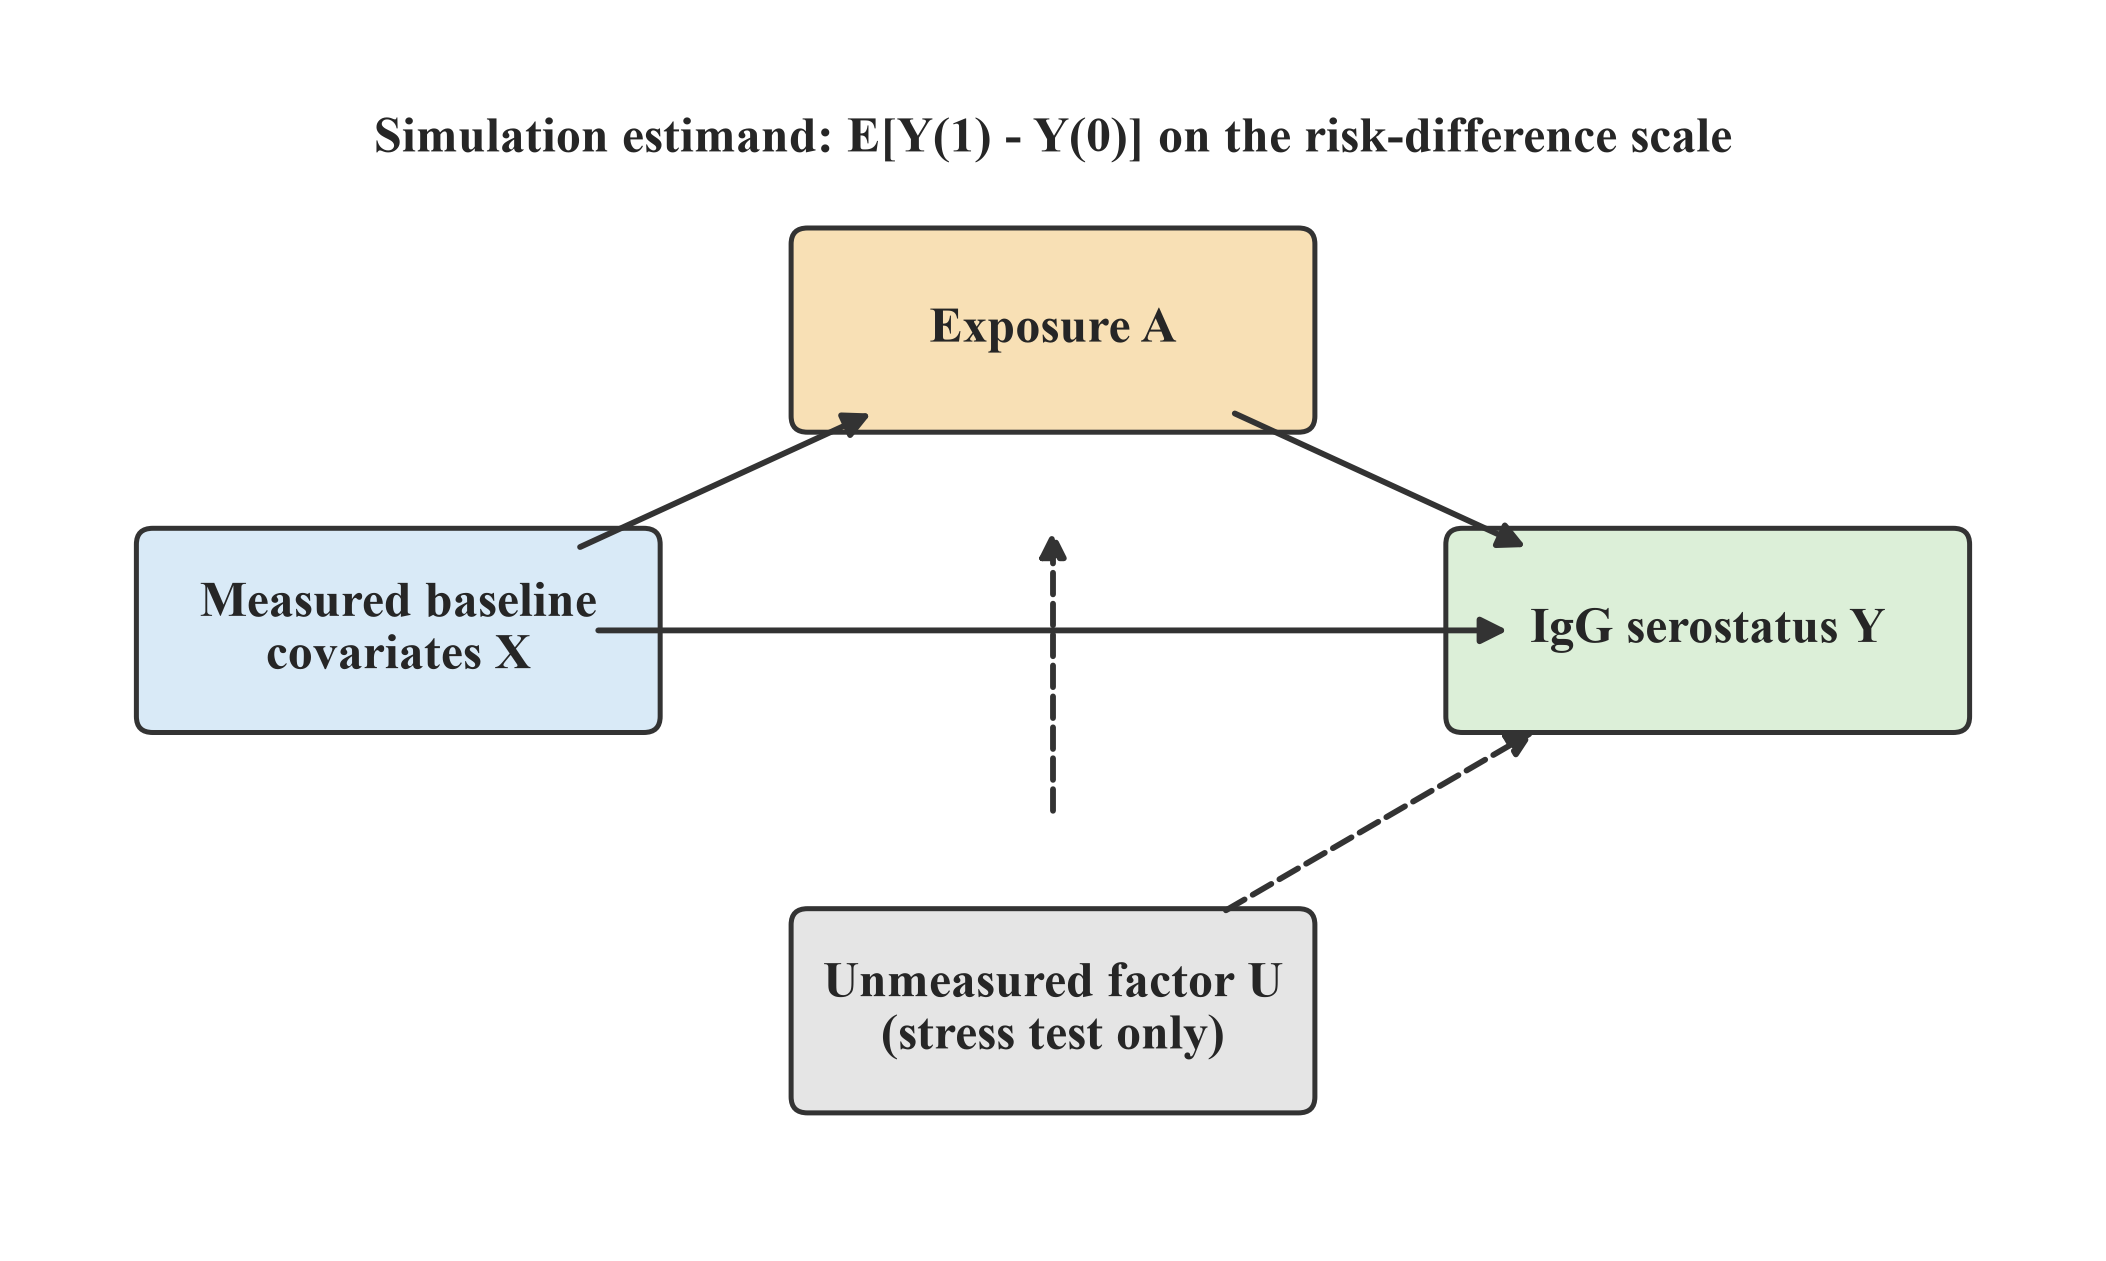

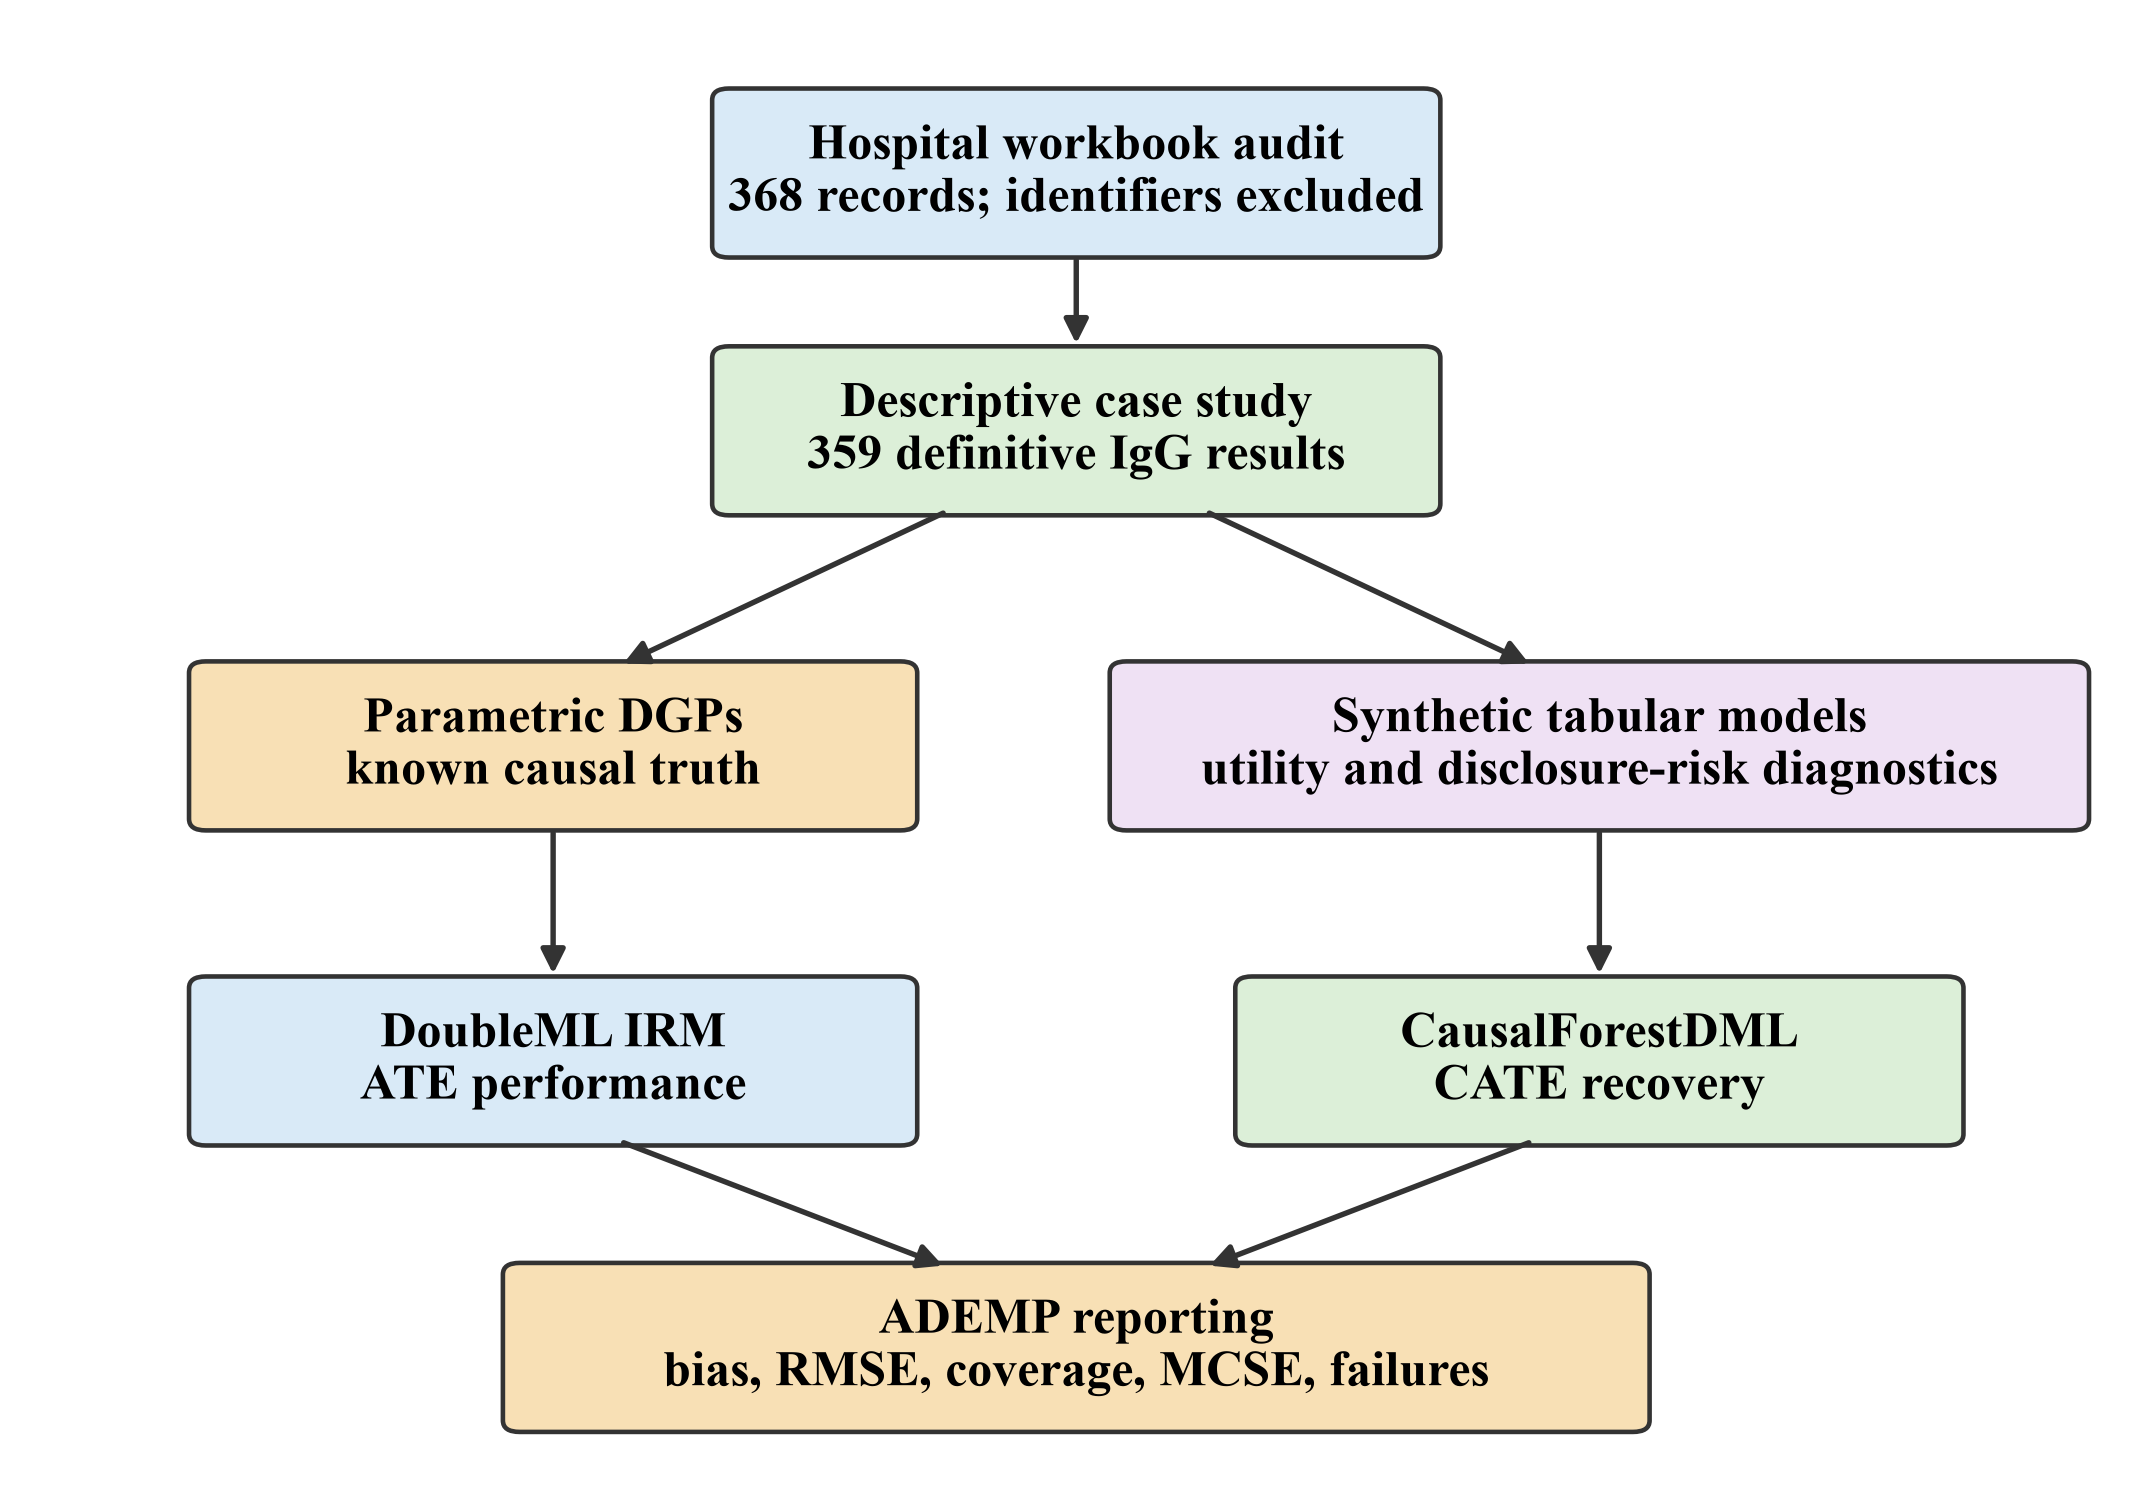

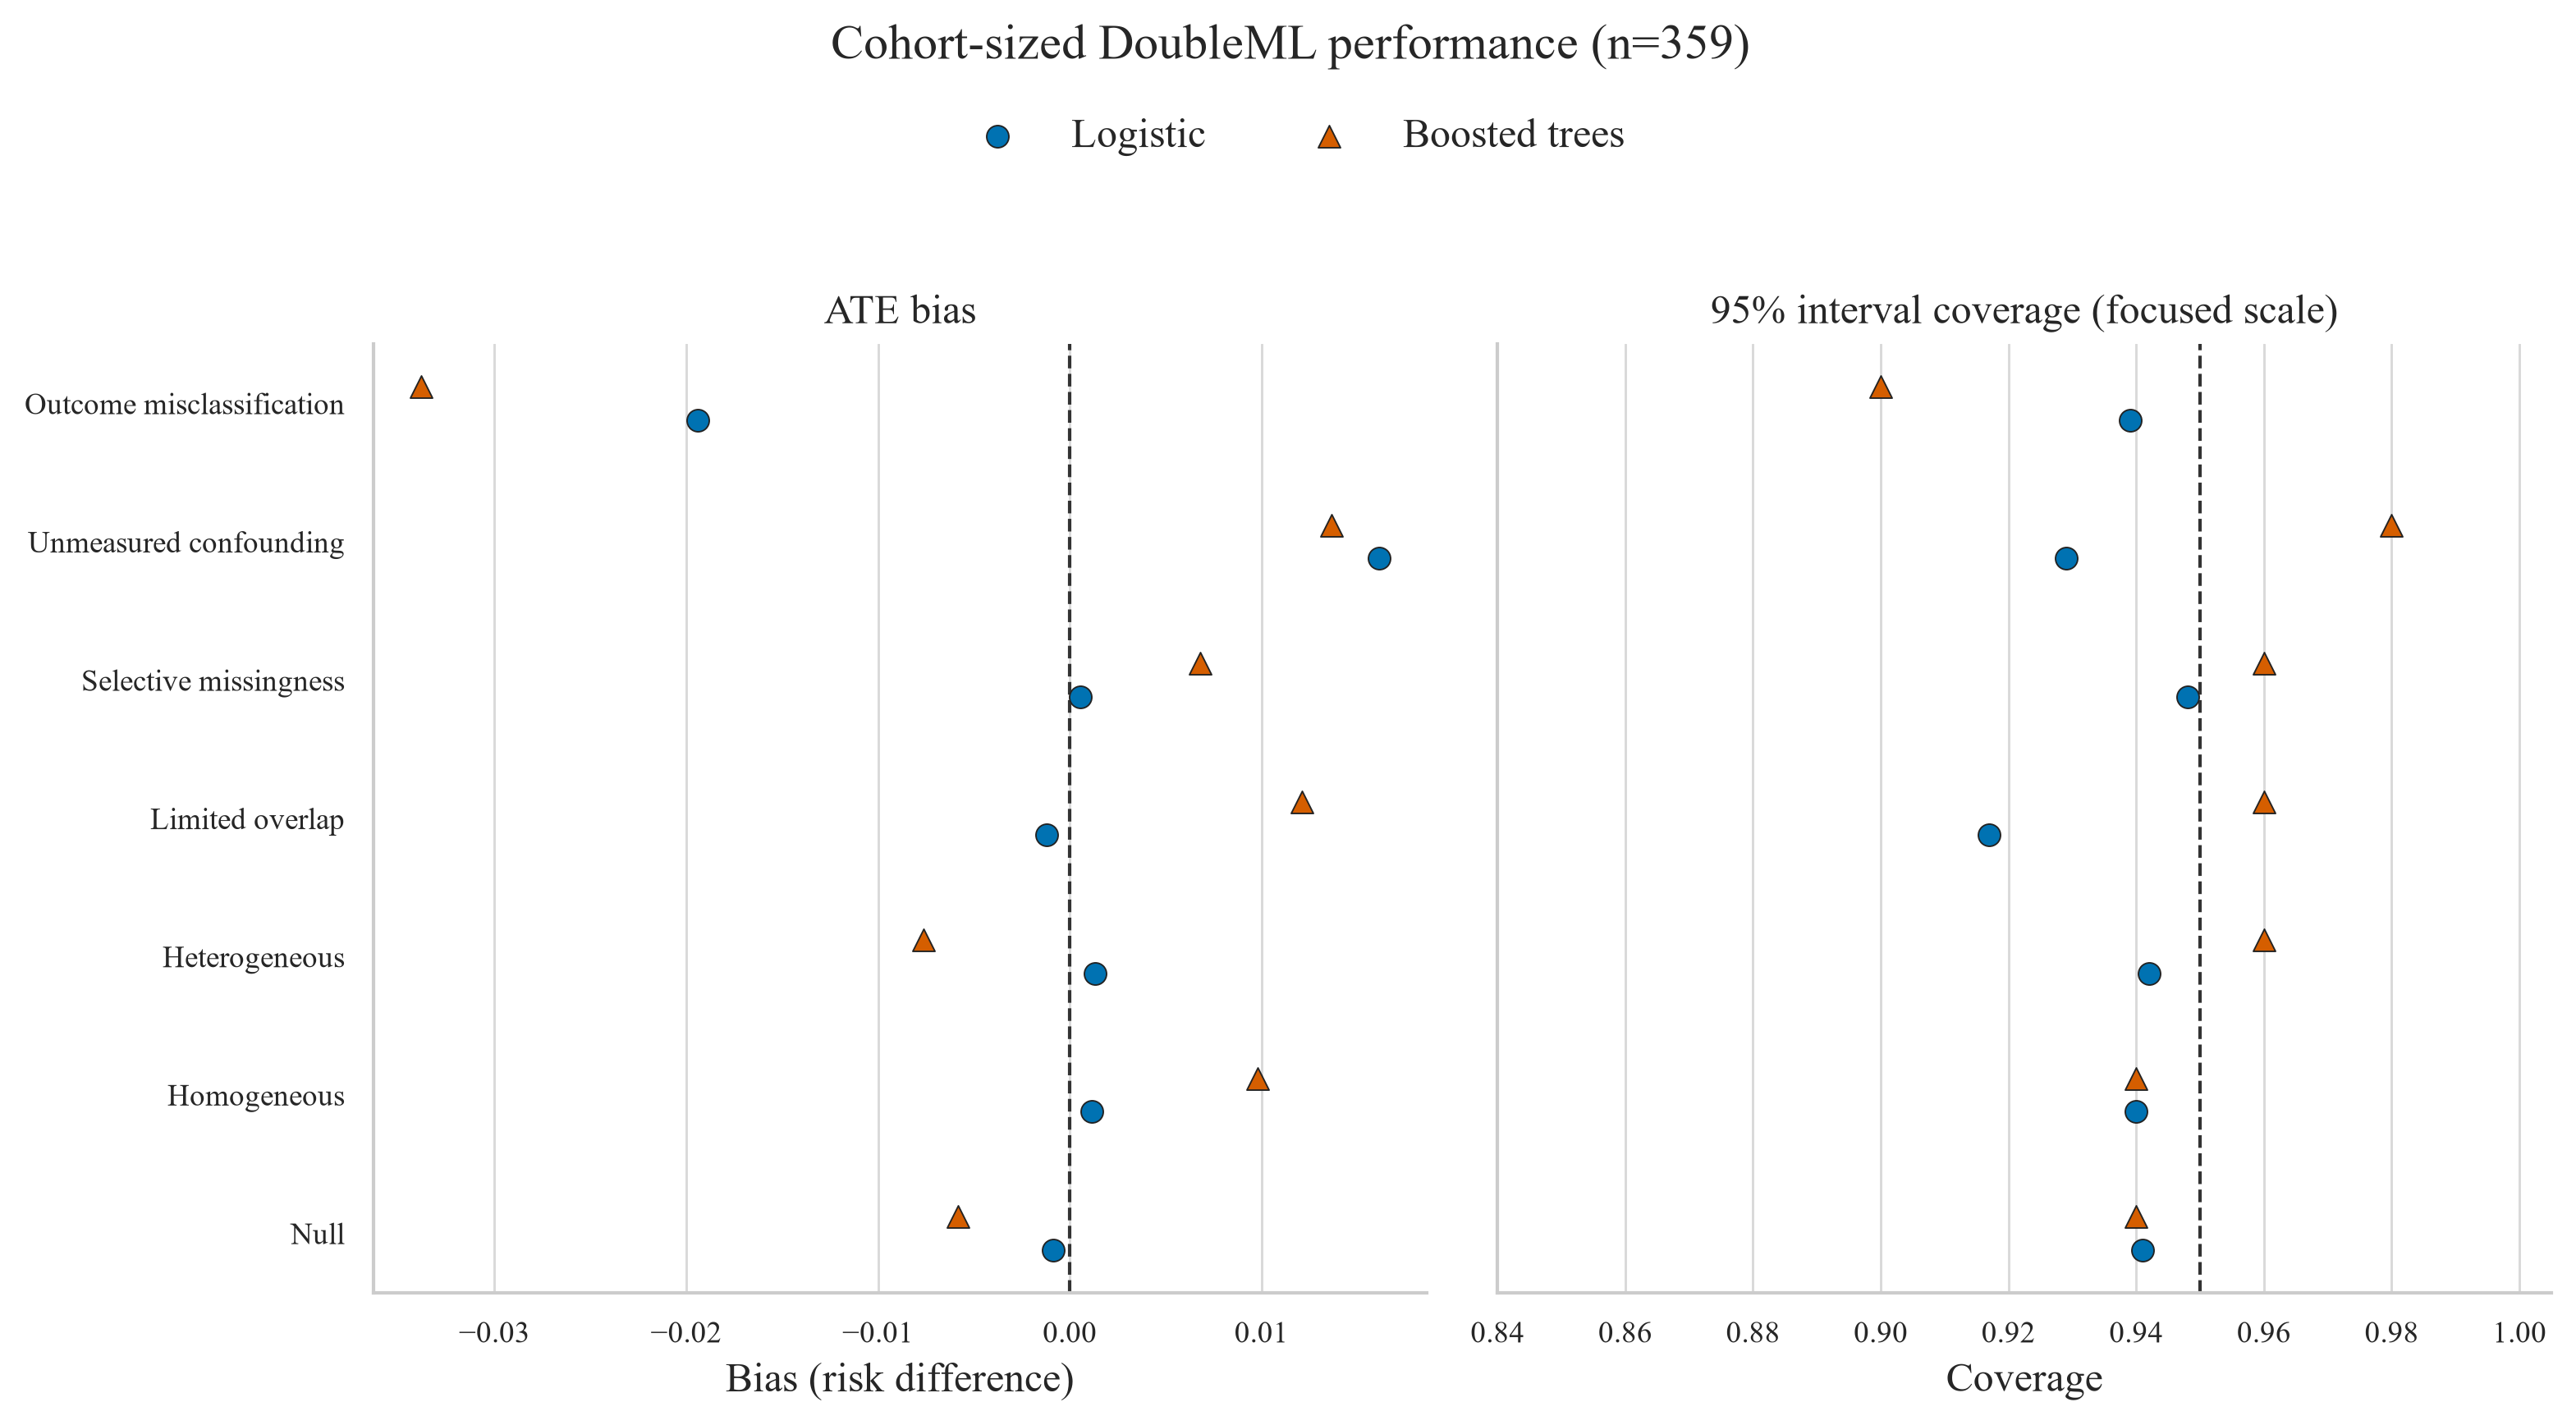

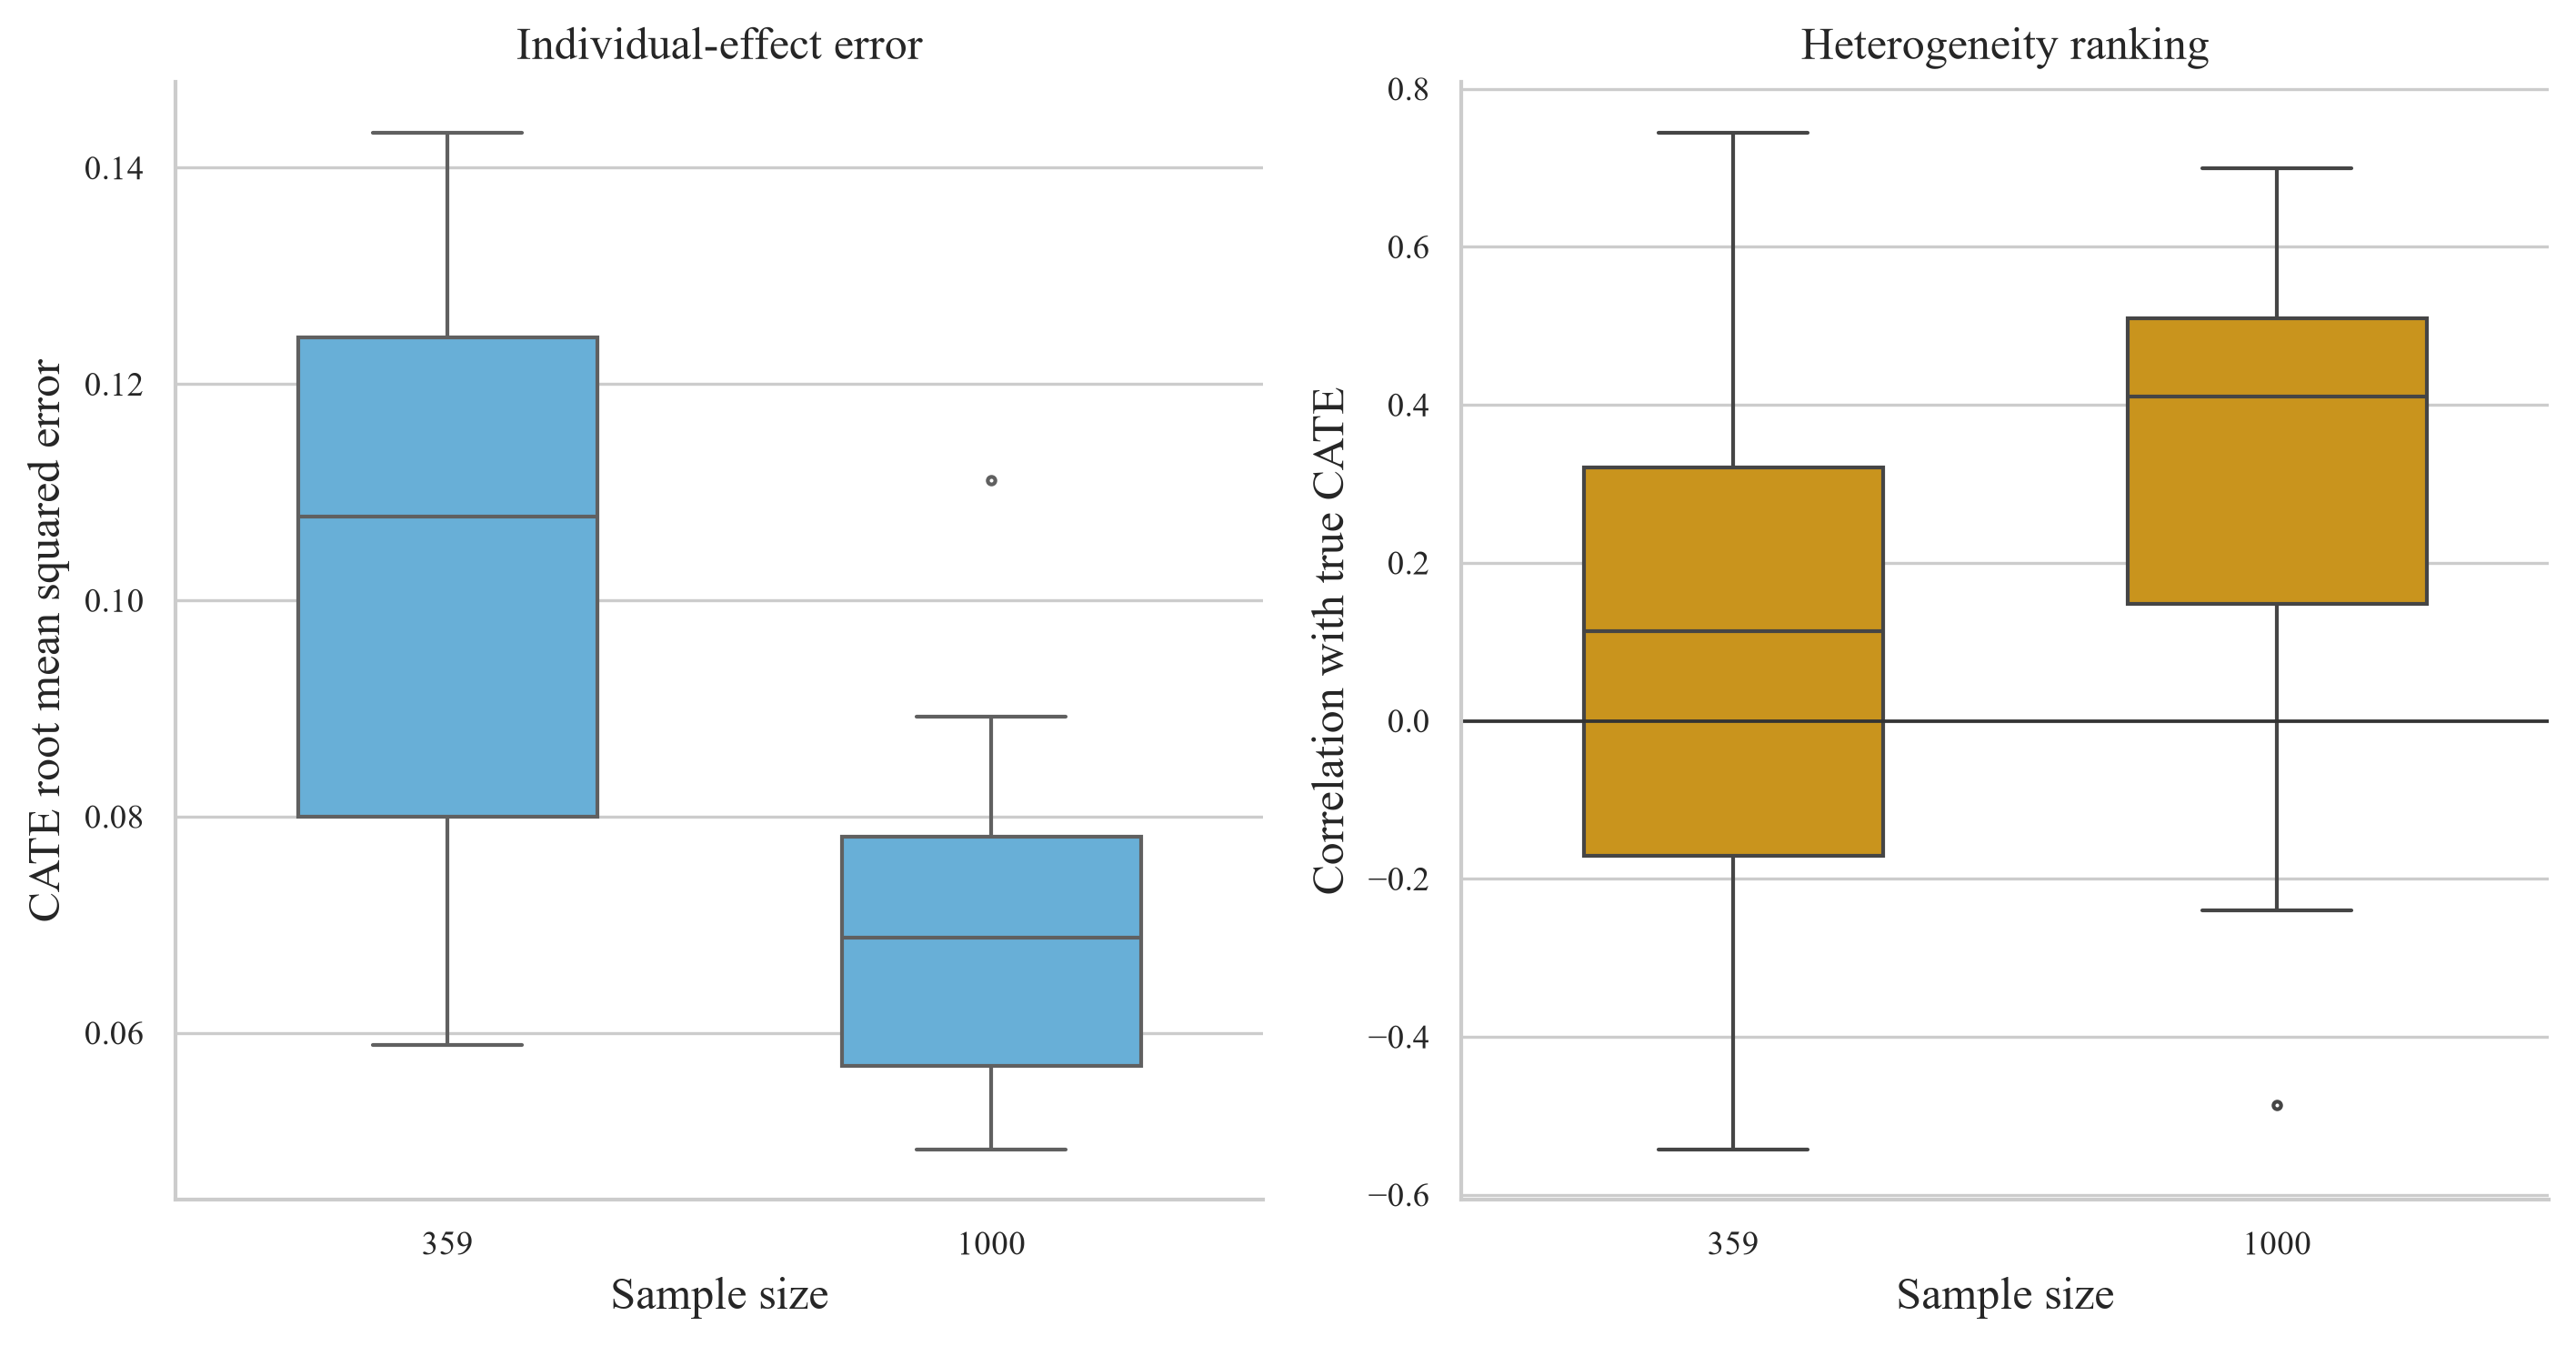

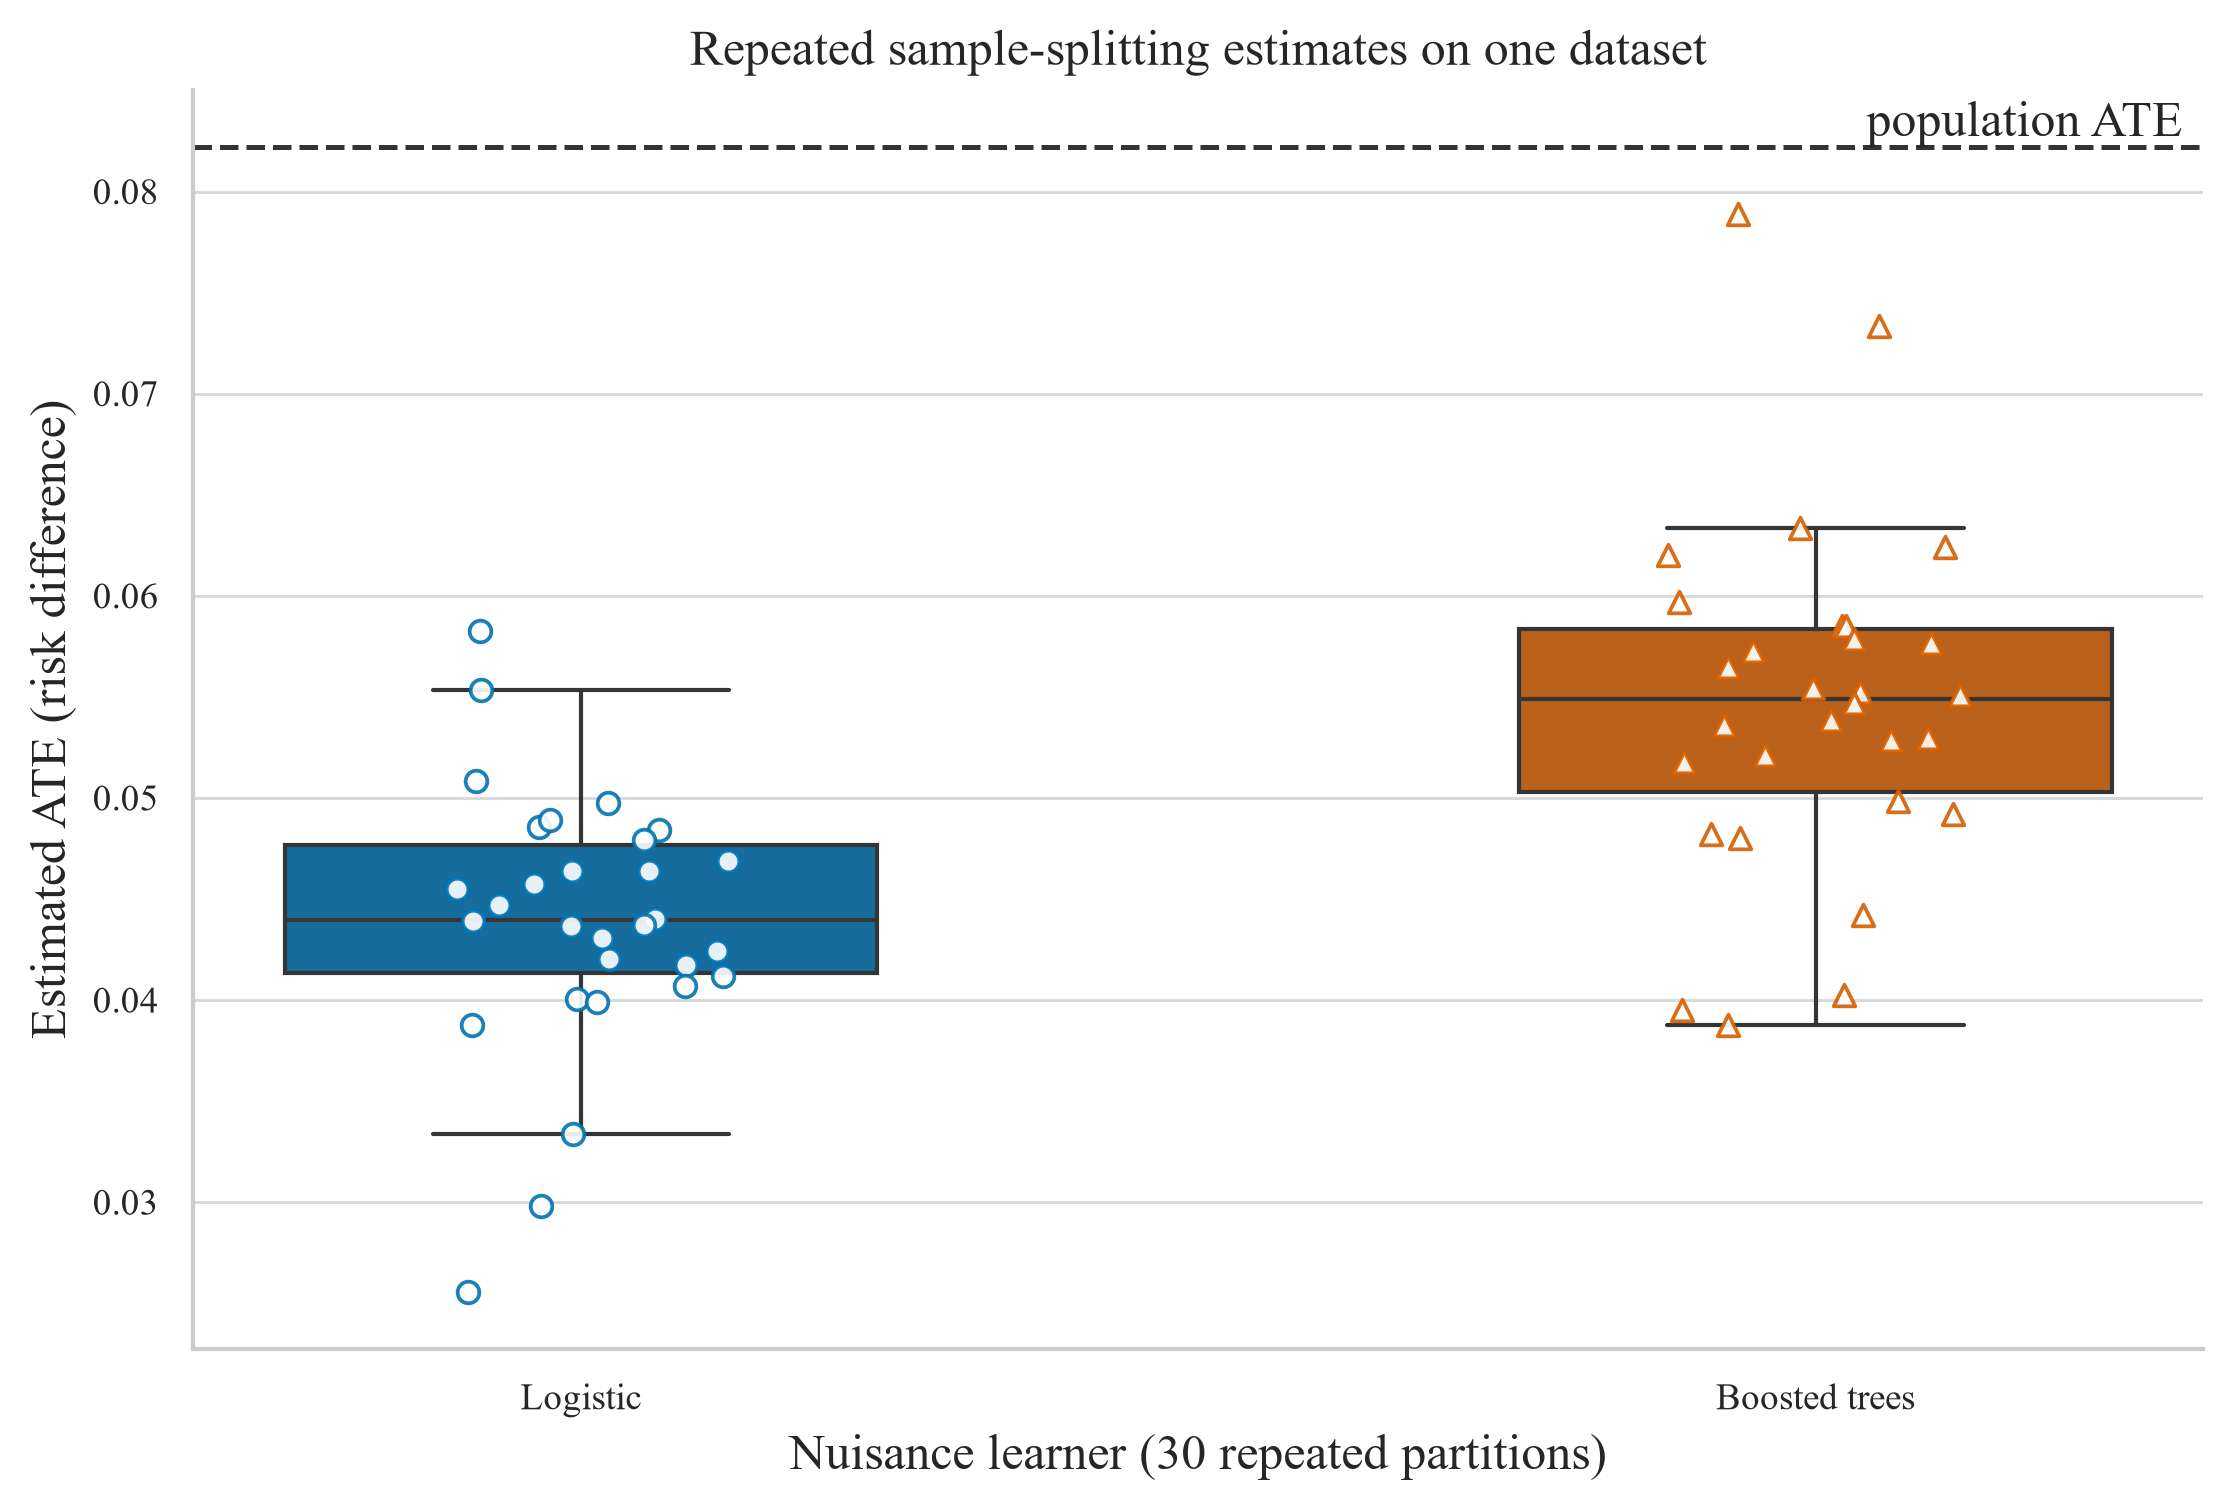

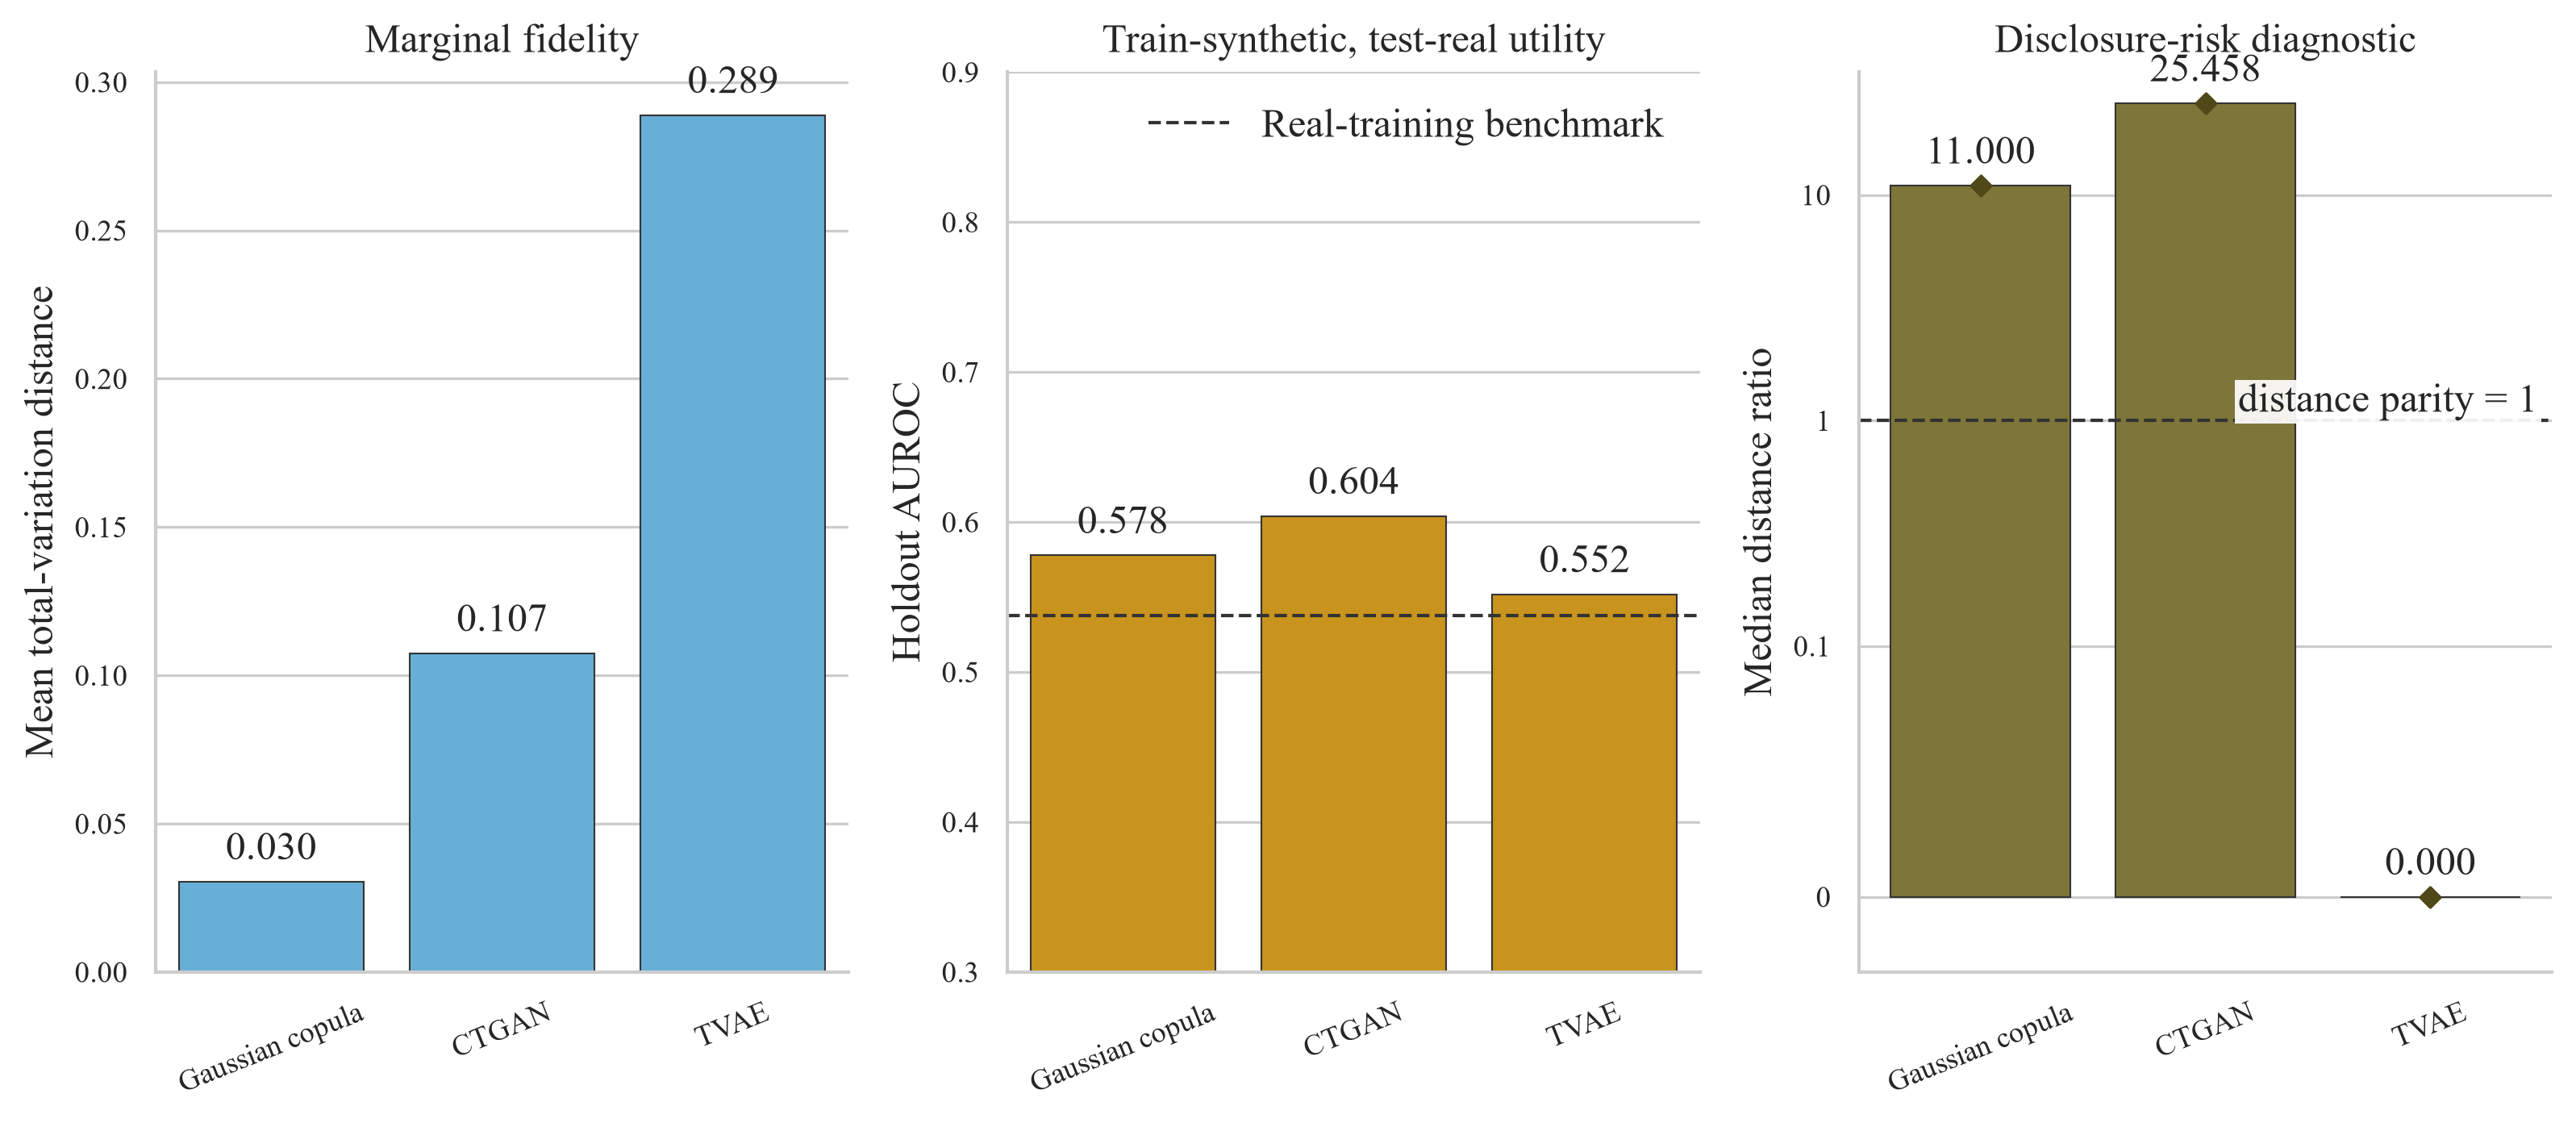

In [9]:
for figure_name in [
    "figure1_dag.png", "figure2_workflow.png", "figure3_dml_performance.png",
    "figure4_forest_performance.png", "figure5_crossfit_stability.png", "figure6_synthetic_benchmark.png",
]:
    figure_path = PACKAGE_ROOT / figure_name
    assert figure_path.exists() and figure_path.stat().st_size > 10_000
    display(Image(filename=str(figure_path), width=850))

## Takeaways

1. **Identification governs interpretation.** Orthogonal scores and flexible nuisance models did not repair omitted confounding, measurement error, or a clinically undefined exposure.
2. **Cohort-sized CATE rankings are unstable.** At n=359, mean correlation with true individual effects was about 0.093; individual treatment-effect claims would be scientifically unjustified.
3. **The hospital workbook is informative for quality control, not causal inference.** Its aggregate IgG proportion describes the tested records only and is not population seroprevalence.
4. **Synthetic data do not add clinical evidence.** Generator rankings were objective-specific; TVAE’s 92.3% exact benchmark-field match rate was catastrophic overfitting and memorization and prohibits release, although it is not a numerical re-identification probability.
5. **Human authorization remains essential.** Before upload, the authors must verify the final files, approve the authorship and declarations, confirm institutional permission for the data-access statement, and retain the ethics approval and assay records for editorial queries.